In [103]:
# === Colab 호환 셋업 (자동 추가) ===
import torch as _t
_t._orig_load = getattr(_t, '_orig_load', _t.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return _t._orig_load(*a, **k)
_t.load = _compat_load
try:
    import matplotlib; matplotlib.rcParams['axes.unicode_minus'] = False
except Exception: pass
print('[colab-compat] torch.load weights_only=False 패치 적용')


[colab-compat] torch.load weights_only=False 패치 적용


In [104]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 52 not upgraded.


In [105]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


### **학습 목표**
---

* 번역 및 챗봇 성능을 측정하기 위한 지표를 이해하고, 용도에 맞게 만들 수 있다.
* NLP task에 맞는 data augmentation의 방법들을 알고, 활용할 수 있다.

### **준비물**
---

터미널을 열고 프로젝트를 위한 디렉토리를 생성해 주세요.

In [106]:
!mkdir -p ./aiffel/transformer_chatbot

아직 KoNLPy가 설치되어 있지 않으시다면, 우분투 환경에서는 아래 소스를 실행하여 설치해 주시고, 다른 OS는 첨부한 공식 문서를 참고하여 설치하시길 바랍니다.

###### Ubuntu

```shell
$ sudo apt-get install g++ openjdk-8-jdk
$ sudo apt-get install curl

$ bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

$ pip install konlpy
```

###### Windows, Mac

* [설치하기 - KoNLPy 0.5.2 documentation](https://konlpy.org/ko/latest/install/)

In [107]:
!python3 -m pip install --upgrade pip
!python3 -m pip install konlpy # Python 3.x
# MeCab 설치하기 (konlpy/master/scripts/mecab.sh 는 현행 Colab에서 자주 실패하므로 비치명적으로 처리)
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh) || true # MeCab 설치하기

mecab-ko is already installed
mecab-ko-dic is already installed
<string>:1: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
mecab-python is already installed
Done.


## **17-2. 번역 데이터 준비**

먼저 번역 모델이 있어야 챗봇을 만들 수 있겠죠? 이번 실습에선 접근성이 좋은 **영어-스페인어 데이터**를 사용하도록 하겠습니다.

### **라이브러리와 데이터 준비하기**
---

필요한 라이브러리를 `import` 해주세요.

In [108]:
import numpy as np
import pandas as pd
import torch
import sentencepiece as spm
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction

import re
import os
import random
import math

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(torch.__version__)

2.11.0+cu128


영어-스페인어 데이터를 다운로드해 주세요.

In [109]:
import urllib.request
import zipfile

zip_filename = "spa-eng.zip"
zip_url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"

urllib.request.urlretrieve(zip_url, zip_filename)

with zipfile.ZipFile(zip_filename, "r") as zip_ref:
    zip_ref.extractall(os.path.dirname(zip_filename))

print("슝=3")

슝=3


다운로드한 데이터가 어떤 지 한 번 열어봅시다. 중복된 데이터가 있을 수 있으니 `list`와 `set`을 사용해 처리해 줍니다.

In [110]:
extracted_folder = "./spa-eng"
file_path = os.path.join(extracted_folder, "spa.txt")

with open(file_path, "r") as f:
    spa_eng_sentences = f.read().splitlines()

spa_eng_sentences = list(set(spa_eng_sentences))
total_sentence_count = len(spa_eng_sentences)
print("Example:", total_sentence_count)

for sen in spa_eng_sentences[0:100][::20]:
    print(">>", sen)

Example: 118964
>> Tom already has a plan.	Tom ya tiene un plan.
>> Tom allowed Mary to leave early.	Tomás dejó que María se retirara temprano.
>> I'm going home now.	Me marcho ya.
>> Tom heard Mary singing in the shower.	Tom escuchó a Mary cantando en la ducha.
>> It is going to rain.	Va a llover.


한 줄에 영어와 스페인어가 둘 다 들어 있네요. \
\
가벼운 전처리를 해줍시다. 먼저 전처리 함수를 만들어 볼까요?

In [111]:
# Q. 전처리 함수를 만들어 보세요. 아래 기능을 추가해주세요.
def preprocess_sentence(sentence):
    sentence = sentence.lower() # 대문자를 소문자로 변환
    sentence = re.sub(r' {2,}', ' ', sentence) # 둘 이상의 공백을 하나의 공백으로 치환
    sentence = sentence.strip() # 문자열 양 끝 공백 제거
    return sentence

모든 데이터에 대해서 같은 전처리를 해줄게요.

In [112]:
spa_eng_sentences = list(map(preprocess_sentence, spa_eng_sentences))

print('슝=3')

슝=3


이제 테스트에 사용할 데이터를 따로 떼어냅니다. 전체 데이터의 0.5% 정도를 테스트용으로 사용할게요.

In [113]:
test_sentence_count = total_sentence_count // 200
print("Test Size: ", test_sentence_count)
print("\n")

train_spa_eng_sentences = spa_eng_sentences[:-test_sentence_count]
test_spa_eng_sentences = spa_eng_sentences[-test_sentence_count:]
print("Train Example:", len(train_spa_eng_sentences))
for sen in train_spa_eng_sentences[0:100][::20]:
    print(">>", sen)
print("\n")
print("Test Example:", len(test_spa_eng_sentences))
for sen in test_spa_eng_sentences[0:100][::20]:
    print(">>", sen)

Test Size:  594


Train Example: 118370
>> tom already has a plan.	tom ya tiene un plan.
>> tom allowed mary to leave early.	tomás dejó que maría se retirara temprano.
>> i'm going home now.	me marcho ya.
>> tom heard mary singing in the shower.	tom escuchó a mary cantando en la ducha.
>> it is going to rain.	va a llover.


Test Example: 594
>> life is very hard.	la vida es muy dura.
>> i never win.	yo nunca gano.
>> they sell fruit, bread, cakes, and many other things.	ellos venden frutas, pan, tortas y muchas otras cosas.
>> he's a tennis player.	él es jugador de tenis.
>> tom put an engagement ring on mary's finger.	tom puso un anillo de compromiso en el dedo de maría.


한 줄에 포함되어 있는 영어와 스페인어를 분리해 줍니다. 영어 문장과 스페인어 문장이 tab으로 연결되어 있으니 `split('\t')`을 사용하면 나눌 수 있겠네요. tab 이전이 영어, 이후가 스페인어 문장입니다. \
\
먼저 함수를 만들어 줍니다.

In [114]:
def split_spa_eng_sentences(spa_eng_sentences):
    spa_sentences = []
    eng_sentences = []
    for spa_eng_sentence in tqdm(spa_eng_sentences):
        eng_sentence, spa_sentence = spa_eng_sentence.split('\t')
        spa_sentences.append(spa_sentence)
        eng_sentences.append(eng_sentence)
    return eng_sentences, spa_sentences

print('슝=3')

슝=3


학습 데이터와 테스트 데이터를 모두 나눠 줍니다.

In [115]:
train_eng_sentences, train_spa_sentences = split_spa_eng_sentences(train_spa_eng_sentences)
print(len(train_eng_sentences))
print(train_eng_sentences[0])
print('\n')
print(len(train_spa_sentences))
print(train_spa_sentences[0])

  0%|          | 0/118370 [00:00<?, ?it/s]

118370
tom already has a plan.


118370
tom ya tiene un plan.


In [116]:
test_eng_sentences, test_spa_sentences = split_spa_eng_sentences(test_spa_eng_sentences)
print(len(test_eng_sentences))
print(test_eng_sentences[0])
print('\n')
print(len(test_spa_sentences))
print(test_spa_sentences[0])

  0%|          | 0/594 [00:00<?, ?it/s]

594
life is very hard.


594
la vida es muy dura.


### **토큰화**
---

이제 문장 데이터를 토큰화를 해야 할 차례입니다. **Sentencepiece** 기반의 토크나이저를 생성해 주는 `generate_tokenizer()` 함수를 정의하여 토크나이저를 얻어보도록 하죠!<br><br>

* [google/sentencepiece](https://github.com/google/sentencepiece)

In [117]:
def generate_tokenizer(corpus,
                       vocab_size,
                       lang="spa-eng",
                       pad_id=0,   # pad token의 일련번호
                       bos_id=1,  # 문장의 시작을 의미하는 bos token(<s>)의 일련번호
                       eos_id=2,  # 문장의 끝을 의미하는 eos token(</s>)의 일련번호
                       unk_id=3):   # unk token의 일련번호
    file = "./%s_corpus.txt" % lang
    model = "%s_spm" % lang

    with open(file, 'w') as f:
        for row in corpus: f.write(str(row) + '\n')

    import sentencepiece as spm
    spm.SentencePieceTrainer.Train(
        '--input=./%s --model_prefix=%s --vocab_size=%d '
        '%s'
        % (file, model, vocab_size, '--bos_id=%d --eos_id=%d --unk_id=%d --pad_id=%d' % (bos_id, eos_id, unk_id, pad_id))
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load('%s.model' % model)

    return tokenizer

print("슝=3")

슝=3


이번엔 한-영 번역 때와 다르게, **두 언어가 단어 사전을 공유**하도록 하겠습니다. 영어와 스페인어 **모두 알파벳**으로 이뤄지는 데다가 같은 **인도유럽어족**이기 때문에 기대할 수 있는 효과가 많아요! 후에 챗봇을 만들 때에도 질문과 답변이 모두 한글로 이루어져 있기 때문에 Embedding 층을 공유하는 것이 성능에 도움이 됩니다. \
\
단어 사전 수는 **20,000**으로 설정하겠습니다. 처리하는데 약간 시간이 걸립니다.

In [118]:
VOCAB_SIZE = 20000
tokenizer = generate_tokenizer(train_eng_sentences + train_spa_sentences, VOCAB_SIZE, 'spa-eng', bos_id=1, eos_id=2, unk_id=3, pad_id=0)

위에서 두 언어 사이에 단어 사전을 공유하기로 하였으므로 Encoder와 Decoder의 전용 토크나이저를 만들지 않고, 방금 만들어진 토크나이저를 두 언어 사이에서 공유하게 됩니다. \
\
토크나이저가 준비되었으니 본격적으로 데이터를 토큰화하도록 하겠습니다. 토큰화를 해주는 함수를 만들어 줍니다.

In [119]:
def make_corpus(sentences, tokenizer):
    corpus = []
    for sentence in tqdm(sentences):
        tokens = tokenizer.encode_as_ids(sentence)
        corpus.append(tokens)
    return corpus

print('슝=3')

슝=3


코퍼스를 사용하기 전에 먼저 토큰화된 코퍼스를 생성해야 합니다. `eng_corpus`와 `spa_corpus`를 정의하는 셀을 이동합니다.

In [120]:
eng_corpus = make_corpus(train_eng_sentences, tokenizer)
spa_corpus = make_corpus(train_spa_sentences, tokenizer)

  0%|          | 0/118370 [00:00<?, ?it/s]

  0%|          | 0/118370 [00:00<?, ?it/s]

영어와 스페인어를 각각 토큰화 해줍니다. 훈련 데이터만 토큰화를 하고, 같은 토크나이저를 사용한다는 점에 주의하세요.

토큰화가 잘 되었는지 확인해 봅시다.

`list` 자료형을 고정 길이로 맞추기 위해 패딩(padding) 작업을 해줍니다. 기존에는 `tf.keras`의 `pad_sequences()`를 사용했지만, 여기서는 PyTorch에 맞춰 직접 구현한 `pad_sequences_custom()`으로 한 번에 데이터셋을 완성하겠습니다! 한 문장의 토큰 길이가 50이 되도록 설정했습니다.

In [121]:
print(train_eng_sentences[0])
print(eng_corpus[0])
print('\n')
print(train_spa_sentences[0])
print(spa_corpus[0])

tom already has a plan.
[6, 451, 77, 5, 393, 4]


tom ya tiene un plan.
[6, 207, 99, 27, 393, 4]


In [122]:
# MAX_LEN = 50
# enc_ndarray = tf.keras.preprocessing.sequence.pad_sequences(eng_corpus, maxlen=MAX_LEN, padding='post')
# dec_ndarray = tf.keras.preprocessing.sequence.pad_sequences(spa_corpus, maxlen=MAX_LEN, padding='post')

# print('슝=3')

In [123]:
MAX_LEN = 50

def pad_sequences_custom(sequences, max_len=50, pad_value=0):
    """
    sequences: list of list (각 문장별 토큰 ID 리스트)
    max_len: 고정할 최대 시퀀스 길이
    pad_value: 패딩에 사용할 값 (일반적으로 0)
    """
    padded_sequences = []

    for seq in sequences:
        # 초과 길이는 자르고
        if len(seq) > max_len:
            seq = seq[:max_len]
        # 부족한 길이는 pad_value로 채우기
        else:
            seq = seq + [pad_value] * (max_len - len(seq))

        padded_sequences.append(seq)

    # 최종적으로 torch.Tensor로 변환 (shape: [batch_size, max_len])
    return torch.tensor(padded_sequences, dtype=torch.long)

enc_ndarray = pad_sequences_custom(eng_corpus, max_len=MAX_LEN, pad_value=0)
dec_ndarray = pad_sequences_custom(spa_corpus, max_len=MAX_LEN, pad_value=0)

print(enc_ndarray.shape)  # 예) [batch_size, 50]
print(dec_ndarray.shape)  # 예) [batch_size, 50]
print("슝=3")

torch.Size([118370, 50])
torch.Size([118370, 50])
슝=3


이제 모델 훈련에 사용될 수 있도록 영어와 스페인어 데이터를 묶어 배치 크기의 텐서로 만들어 줍니다. 데이터 셋이 완성 되었어요!

In [124]:
# BATCH_SIZE = 64
# train_dataset = tf.data.Dataset.from_tensor_slices((enc_ndarray, dec_ndarray)).batch(batch_size=BATCH_SIZE)

# print('슝=3')

In [125]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_dataset = TensorDataset(enc_ndarray, dec_ndarray)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

print("슝=3")

슝=3


이제 모델을 만들러 가봅시다~!

## **17-3. 번역 모델 만들기**

### **트랜스포머 구현하기**
---

**생성된 데이터를 학습할 수 있는 멋진 트랜스포머(Transformer)를 구현하세요!** \
\
트랜스포머 구조가 잘 기억나지 않으시거나 구현에 도움이 필요하시면 아래 링크를 참고해 주세요.<br><br>

* [위키독스: 트랜스포머](https://wikidocs.net/31379)
* [Trax: Transformer](https://github.com/google/trax/blob/master/trax/models/transformer.py)
* [`nn.Transformer` 와 torchtext로 시퀀스-투-시퀀스(Sequence-to-Sequence) 모델링하기](https://tutorials.pytorch.kr/beginner/transformer_tutorial.html)

<br>단, Encoder와 Decoder 각각의 Embedding과 출력층의 Linear, 총 3개의 레이어가 Weight를 공유할 수 있게 하세요! \
\
하이퍼파라미터는 아래와 동일하게 정의합니다.

```python
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared_fc=True,
    shared_emb=True)
```

아래 코드 블록에 모듈별로 하나씩 구현해 봅시다.

###### Positional Encoding

In [126]:
# Positional Encoding 구현
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table
print("슝=3")

슝=3


<details><summary>예시 답안</summary>

```python
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table
```
</details>

###### 마스크 생성

In [127]:
# Mask  생성하기
def generate_padding_mask(seq):
    seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
    return seq[:, tf.newaxis, tf.newaxis, :]

def generate_lookahead_mask(size):
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return mask

def generate_masks(src, tgt):
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(src)

    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])
    dec_tgt_padding_mask = generate_padding_mask(tgt)
    dec_mask = tf.maximum(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask
print("슝=3")

슝=3


<details><summary>예시 답안</summary>

```python
def generate_padding_mask(seq):
    # (seq == 0)인 위치를 1로 표시 -> [batch, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()

def generate_lookahead_mask(size):
    # 주대각선 위쪽(미래 토큰)을 1로 채운다
    return torch.triu(torch.ones(size, size), diagonal=1)

def generate_masks(src, tgt):
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(src)

    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])
    dec_tgt_padding_mask = generate_padding_mask(tgt)
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)

    dec_mask = torch.max(dec_tgt_padding_mask.to(device),
                         dec_lookahead_mask.to(device))
    return enc_mask, dec_enc_mask, dec_mask
```
</details>


In [128]:
import torch

def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")

슝=3


###### Multi-head Attention

In [129]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Multi Head Attention 구현
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        self.depth = d_model // self.num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)

        return out, attentions


    def split_heads(self, x):
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3) # [batch_size, num_heads, seq_len, depth]

        return x

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)

        return x


    def forward(self, Q, K, V, mask):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)

        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights
print("슝=3")

슝=3


<details><summary>예시 답안</summary>

```python
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        QK = torch.matmul(Q, K.transpose(-1, -2))
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)
        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)          # [B, heads, seq, depth]

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        return x.view(bsz, seq_len, self.d_model)

    def forward(self, Q, K, V, mask=None):
        WQ, WK, WV = self.W_q(Q), self.W_k(K), self.W_v(V)
        WQ, WK, WV = self.split_heads(WQ), self.split_heads(WK), self.split_heads(WV)
        out, attention_weights = self.scaled_dot_product_attention(WQ, WK, WV, mask)
        out = self.combine_heads(out)
        out = self.linear(out)
        return out, attention_weights
```
</details>


In [130]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights

print("슝=3")

슝=3


###### Position-wise Feed Forward Network

In [131]:
# # Position-wise Feed Forward Network 구현
# class PoswiseFeedForwardNet(tf.keras.layers.Layer):
#     def __init__(self, d_model, d_ff):
#         super(PoswiseFeedForwardNet, self).__init__()
#         self.d_model = d_model
#         self.d_ff = d_ff

#         self.fc1 = tf.keras.layers.Dense(d_ff, activation='relu')
#         self.fc2 = tf.keras.layers.Dense(d_model)

#     def call(self, x):
#         out = self.fc1(x)
#         out = self.fc2(out)

#         return out
# print("슝=3")

<details><summary>예시 답안</summary>

```python
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))   # Dense(d_ff) + ReLU
        out = self.fc2(out)            # Dense(d_model)
        return out
```
</details>


In [132]:
import torch
import torch.nn as nn

class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

print("슝=3")

슝=3


###### Encoder Layer

In [133]:
# # Encoder의 레이어 구현
# class EncoderLayer(tf.keras.layers.Layer):
#     def __init__(self, d_model, n_heads, d_ff, dropout):
#         super(EncoderLayer, self).__init__()

#         self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
#         self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

#         self.norm_1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
#         self.norm_2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

#         self.do = tf.keras.layers.Dropout(dropout)

#     def call(self, x, mask):
#         '''
#         Multi-Head Attention
#         '''
#         residual = x
#         out = self.norm_1(x)
#         out, enc_attn = self.enc_self_attn(out, out, out, mask)
#         out = self.do(out)
#         out += residual

#         '''
#         Position-Wise Feed Forward Network
#         '''
#         residual = out
#         out = self.norm_2(out)
#         out = self.ffn(out)
#         out = self.do(out)
#         out += residual

#         return out, enc_attn
# print("슝=3")

<details><summary>예시 답안</summary>

```python
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual
        return out, enc_attn
```
</details>


In [134]:
import torch
import torch.nn as nn

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual  # residual connection

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual  # residual connection

        return out, enc_attn

print("슝=3")

슝=3


In [135]:
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        # 파이썬 list 대신 nn.ModuleList를 써야 파라미터가 제대로 등록됩니다.
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns

In [136]:
import torch
import torch.nn as nn

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn

###### Decoder Layer

In [137]:
# # Decoder 레이어 구현
# class DecoderLayer(tf.keras.layers.Layer):
#     def __init__(self, d_model, num_heads, d_ff, dropout):
#         super(DecoderLayer, self).__init__()

#         self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
#         self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)

#         self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

#         self.norm_1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
#         self.norm_2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
#         self.norm_3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

#         self.do = tf.keras.layers.Dropout(dropout)

#     def call(self, x, enc_out, dec_enc_mask, padding_mask):
#         '''
#         Masked Multi-Head Attention
#         '''
#         residual = x
#         out = self.norm_1(x)
#         out, dec_attn = self.dec_self_attn(out, out, out, padding_mask)
#         out = self.do(out)
#         out += residual

#         '''
#         Multi-Head Attention
#         '''
#         residual = out
#         out = self.norm_2(out)
#         # Q, K, V 순서에 주의하세요!
#         out, dec_enc_attn = self.enc_dec_attn(Q=out, K=enc_out, V=enc_out, mask=dec_enc_mask)
#         out = self.do(out)
#         out += residual

#         '''
#         Position-Wise Feed Forward Network
#         '''
#         residual = out
#         out = self.norm_3(out)
#         out = self.ffn(out)
#         out = self.do(out)
#         out += residual

#         return out, dec_attn, dec_enc_attn
# print("슝=3")

<details><summary>예시 답안</summary>

```python
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn  = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # 1) Masked Multi-Head Attention (디코더 자기어텐션)
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # 2) Encoder-Decoder Attention (Q, K, V 순서 주의: Q=디코더, K=V=인코더 출력)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # 3) Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn
```
</details>


In [138]:
import torch
import torch.nn as nn

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn

print("슝=3")

슝=3


###### Encoder

In [139]:
# # Encoder 구현
# class Encoder(tf.keras.Model):
#     def __init__(self,
#                     n_layers,
#                     d_model,
#                     n_heads,
#                     d_ff,
#                     dropout):
#         super(Encoder, self).__init__()
#         self.n_layers = n_layers
#         self.enc_layers = [EncoderLayer(d_model, n_heads, d_ff, dropout)
#                         for _ in range(n_layers)]

#         self.do = tf.keras.layers.Dropout(dropout)

#     def call(self, x, mask):
#         out = x

#         enc_attns = list()
#         for i in range(self.n_layers):
#             out, enc_attn = self.enc_layers[i](out, mask)
#             enc_attns.append(enc_attn)

#         return out, enc_attns
# print("슝=3")

<details><summary>예시 답안</summary>

```python
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.n_layers = n_layers
        # 파이썬 list 대신 nn.ModuleList를 써야 파라미터가 제대로 등록됩니다.
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns
```
</details>


In [140]:
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)  # 필요 시 입력에 dropout 적용 가능

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns

# 사용 예시: Encoder 인스턴스 생성 후 forward 호출
# encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
# out, enc_attns = encoder(x, mask)
print("슝=3")

슝=3


###### Decoder

In [141]:
# # Decoder 구현
# class Decoder(tf.keras.Model):
#     def __init__(self,
#                     n_layers,
#                     d_model,
#                     n_heads,
#                     d_ff,
#                     dropout):
#         super(Decoder, self).__init__()
#         self.n_layers = n_layers
#         self.dec_layers = [DecoderLayer(d_model, n_heads, d_ff, dropout)
#                             for _ in range(n_layers)]

#     def call(self, x, enc_out, dec_enc_mask, padding_mask):
#         out = x

#         dec_attns = list()
#         dec_enc_attns = list()
#         for i in range(self.n_layers):
#             out, dec_attn, dec_enc_attn = \
#             self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)

#             dec_attns.append(dec_attn)
#             dec_enc_attns.append(dec_enc_attn)

#         return out, dec_attns, dec_enc_attns
# print("슝=3")

<details><summary>예시 답안</summary>

```python
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns, dec_enc_attns = [], []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](
                out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns
```
</details>


In [142]:
import torch
import torch.nn as nn

class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns

print("슝=3")

슝=3


###### Transformer 전체 모델 조립

In [143]:
# class Transformer(tf.keras.Model):
#     def __init__(self,
#                     n_layers,
#                     d_model,
#                     n_heads,
#                     d_ff,
#                     src_vocab_size,
#                     tgt_vocab_size,
#                     pos_len,
#                     dropout=0.2,
#                     shared_fc=True,
#                     shared_emb=False):
#         super(Transformer, self).__init__()

#         self.d_model = tf.cast(d_model, tf.float32)

#         if shared_emb:
#             self.enc_emb = self.dec_emb = \
#             tf.keras.layers.Embedding(src_vocab_size, d_model)
#         else:
#             self.enc_emb = tf.keras.layers.Embedding(src_vocab_size, d_model)
#             self.dec_emb = tf.keras.layers.Embedding(tgt_vocab_size, d_model)

#         self.pos_encoding = positional_encoding(pos_len, d_model)
#         self.do = tf.keras.layers.Dropout(dropout)

#         self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
#         self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

#         self.fc = tf.keras.layers.Dense(tgt_vocab_size)

#         self.shared_fc = shared_fc

#         if shared_fc:
#             self.fc.set_weights(tf.transpose(self.dec_emb.weights))

#     def embedding(self, emb, x):
#         seq_len = x.shape[1]

#         out = emb(x)

#         if self.shared_fc: out *= tf.math.sqrt(self.d_model)

#         out += self.pos_encoding[np.newaxis, ...][:, :seq_len, :]
#         out = self.do(out)

#         return out


#     def call(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
#         enc_in = self.embedding(self.enc_emb, enc_in)
#         dec_in = self.embedding(self.dec_emb, dec_in)

#         enc_out, enc_attns = self.encoder(enc_in, enc_mask)

#         dec_out, dec_attns, dec_enc_attns = \
#         self.decoder(dec_in, enc_out, dec_enc_mask, dec_mask)

#         logits = self.fc(dec_out)

#         return logits, enc_attns, dec_attns, dec_enc_attns
# print("슝=3")

<details><summary>예시 답안</summary>

```python
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super().__init__()
        self.d_model = float(d_model)

        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # positional_encoding 결과(넘파이)를 buffer로 등록 (학습 대상 아님)
        pe = positional_encoding(pos_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pe, dtype=torch.float32))

        self.do = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # TF의 set_weights(transpose(...)) 대신, PyTorch는 weight를 직접 공유
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        return self.do(out)

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)
        enc_out, enc_attns = self.encoder(enc_in, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(
            dec_in, enc_out, dec_enc_mask, dec_mask)
        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns
```
</details>


In [144]:
import torch
import torch.nn as nn
import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        seq_len = x.size(1)
        out = emb(x)  # [batch_size, seq_len, d_model]
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


In [145]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# MultiHeadAttention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        QK = torch.matmul(Q, K.transpose(-1, -2))
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)
        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)
        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)
        out, attention_weights = self.scaled_dot_product_attention(WQ_splits, WK_splits, WV_splits, mask)
        out = self.combine_heads(out)
        out = self.linear(out)
        return out, attention_weights

# PoswiseFeedForwardNet
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))
        out = self.fc2(out)
        return out

# EncoderLayer
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual

        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual
        return out, enc_attn

# Encoder
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns

# DecoderLayer
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual
        return out, dec_attn, dec_enc_attn

# Decoder
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns
print("슝=3")

슝=3


###### 모델 인스턴스 생성

In [146]:
# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared_fc=True,
    shared_emb=True)

transformer = transformer.to(device)

d_model = 512

print("슝=3")

슝=3


<details><summary>예시 답안</summary>

```python
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared_fc=True,
    shared_emb=True)

d_model = 512
```
</details>

###### Learning Rate Scheduler

In [147]:
# # Learning Rate Scheduler 구현
# class LearningRateScheduler(tf.keras.optimizers.schedules.LearningRateSchedule):
#     def __init__(self, d_model, warmup_steps=4000):
#         super(LearningRateScheduler, self).__init__()

#         self.d_model = d_model
#         self.warmup_steps = warmup_steps

#     def __call__(self, step):
#         arg1 = step ** -0.5
#         arg2 = step * (self.warmup_steps ** -1.5)

#         return (self.d_model ** -0.5) * tf.math.minimum(arg1, arg2)
# print("슝=3")

In [148]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=60): # 4000
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

print("슝=3")

슝=3


<details><summary>예시 답안</summary>

```python
# PyTorch에는 TF의 LearningRateSchedule 베이스 클래스가 없으므로 일반 클래스로 구현하고,
# 학습 루프에서 매 스텝 optimizer의 lr을 직접 갱신합니다.
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)
```
</details>


###### Learning Rate & Optimizer

In [149]:
# # Learning Rate 인스턴스 선언 & Optimizer 구현
# learning_rate = LearningRateScheduler(d_model)

# optimizer = tf.keras.optimizers.Adam(learning_rate,
#                                         beta_1=0.9,
#                                         beta_2=0.98,
#                                         epsilon=1e-9)
# print("슝=3")

<details><summary>예시 답안</summary>

```python
learning_rate = LearningRateScheduler(d_model)

# TF와 달리 스케줄러를 optimizer에 넣을 수 없으므로 초기 lr만 지정하고,
# 학습 루프에서 learning_rate(step) 값으로 param_group['lr']을 갱신합니다.
optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)
```
</details>


In [150]:
# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(d_model)

# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)

print("슝=3")

슝=3


###### Loss Function 정의

In [151]:
# # Loss Function 정의
# loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
#     from_logits=True, reduction='none')

# def loss_function(real, pred):
#     mask = tf.math.logical_not(tf.math.equal(real, 0))
#     loss_ = loss_object(real, pred)

#     mask = tf.cast(mask, dtype=loss_.dtype)
#     loss_ *= mask

#     return tf.reduce_sum(loss_)/tf.reduce_sum(mask)
# print("슝=3")

<details><summary>예시 답안</summary>

```python
def loss_function(real, pred):
    # real: [B, T] 정답 인덱스, pred: [B, T, V] logits
    loss_ = F.cross_entropy(
        pred.contiguous().view(-1, pred.size(-1)),
        real.contiguous().view(-1),
        reduction='none')           # from_logits=True, reduction='none'에 해당
    loss_ = loss_.view(real.size())

    mask = (real != 0).float()      # 패딩(0)은 손실 계산에서 제외
    loss_ = loss_ * mask
    return loss_.sum() / mask.sum()
```
</details>


In [152]:
import torch
import torch.nn.functional as F

def loss_function(real, pred):
    """
    real: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
    """

    real = real.to(device)
    pred = pred.to(device)

    # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction='none')
    # 다시 (batch_size, seq_len)로 reshape
    loss_ = loss_.view(real.size())

    # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
    return loss_.sum() / mask.sum()

print("슝=3")

슝=3


###### Train Step 정의

In [153]:
# # Train Step 정의
# @tf.function()
# def train_step(src, tgt, model, optimizer):
#     tgt_in = tgt[:, :-1]  # Decoder의 input
#     gold = tgt[:, 1:]     # Decoder의 output과 비교하기 위해 right shift를 통해 생성한 최종 타겟

#     enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

#     with tf.GradientTape() as tape:
#         predictions, enc_attns, dec_attns, dec_enc_attns = \
#         model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
#         loss = loss_function(gold, predictions)

#     gradients = tape.gradient(loss, model.trainable_variables)
#     optimizer.apply_gradients(zip(gradients, model.trainable_variables))

#     return loss, enc_attns, dec_attns, dec_enc_attns
# print("슝=3")

<details><summary>예시 답안</summary>

```python
def train_step(src, tgt, model, optimizer):
    model.train()
    optimizer.zero_grad()

    tgt_in = tgt[:, :-1]   # Decoder input
    gold   = tgt[:, 1:]    # right-shift한 최종 타겟

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    predictions, enc_attns, dec_attns, dec_enc_attns = \
        model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(gold, predictions)

    loss.backward()        # tf.GradientTape 대신 autograd
    optimizer.step()       # apply_gradients에 해당
    return loss, enc_attns, dec_attns, dec_enc_attns
```
</details>


In [154]:
def train_step(src, tgt, model, optimizer):
    model.train()  # 모델을 training 모드로 전환
    optimizer.zero_grad()

    # tgt의 오른쪽 시프트: decoder input과 gold target 분리
    tgt_in = tgt[:, :-1]  # Decoder의 입력
    gold = tgt[:, 1:]     # Decoder의 정답(target)

    # 마스크 생성 (generate_masks는 PyTorch용으로 변환된 함수여야 합니다)
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(device)
    tgt_in = tgt_in.to(device)
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    # 모델 forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    # loss 계산
    loss = loss_function(gold, predictions)

    # 역전파 수행 및 파라미터 업데이트
    loss.backward()
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


###### 훈련을 시키자!

In [155]:
# # Q. 위의 코드를 활용하여 모델을 훈련시켜봅시다!
# EPOCHS = 3

# for epoch in range(EPOCHS):
#     total_loss = 0

#     dataset_count = tf.data.experimental.cardinality(train_dataset).numpy()
#     tqdm_bar = tqdm(total=dataset_count)

#     for (batch, (src, tgt)) in enumerate(train_dataset):
#         loss, enc_attns, dec_attns, dec_enc_attns = train_step(src, tgt, transformer, optimizer)
#         total_loss += loss
#         tqdm_bar.set_postfix({"Batch Loss": f"{loss.numpy():.4f}"})
#         tqdm_bar.update(1)

#     tqdm_bar.close()
#     print(f"Epoch {epoch+1}, Loss: {total_loss.numpy() / dataset_count:.4f}")

In [156]:
%%time

EPOCHS = 3
global_step = 0  # LR 스케줄 갱신에 사용하는 전역 스텝 카운터

for epoch in range(EPOCHS):
    total_loss = 0.0
    dataset_count = len(train_dataloader)  # train_loader는 PyTorch DataLoader입니다.
    tqdm_bar = tqdm(total=dataset_count)

    for batch, (src, tgt) in enumerate(train_dataloader):
        # Warmup 스케줄에 맞춰 매 스텝 optimizer의 learning rate를 갱신합니다.
        # (TF에서는 스케줄러를 optimizer에 넣으면 자동 적용되지만, PyTorch에서는 직접 갱신해야 합니다.)
        global_step += 1
        lr = learning_rate(global_step)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        # train_step 함수는 (loss, enc_attns, dec_attns, dec_enc_attns)를 반환합니다.
        loss, enc_attns, dec_attns, dec_enc_attns = train_step(src, tgt, transformer, optimizer)

        total_loss += loss.item()  # PyTorch에서는 loss.numpy() 대신 loss.item() 사용
        tqdm_bar.set_postfix({"Batch Loss": f"{loss.item():.4f}"})
        tqdm_bar.update(1)

    tqdm_bar.close()
    print(f"Epoch {epoch+1}, Loss: {total_loss / dataset_count:.4f}")

  0%|          | 0/1850 [00:00<?, ?it/s]

Epoch 1, Loss: 6722.2019


  0%|          | 0/1850 [00:00<?, ?it/s]

Epoch 2, Loss: 3084.1331


  0%|          | 0/1850 [00:00<?, ?it/s]

Epoch 3, Loss: 1730.6596
CPU times: user 9min 19s, sys: 2.03 s, total: 9min 22s
Wall time: 6min 54s


## **17-4. 번역 성능 측정하기 (1) BLEU Score**

멋진 번역 성능 측정 지표인 **BLEU Score**를 기억하시나요? 번역 모델을 훈련한 김에 라이브러리를 활용해서 간단하게 BLEU Score를 실습해 보겠습니다!<br><br>

* [BLEU](https://en.wikipedia.org/wiki/BLEU)

### **NLTK를 활용한 BLEU Score**
---

**NLTK**는 **N**atural **L**anguage **T**ool **K**it 의 준말로 이름부터 자연어 처리에 큰 도움이 될 것 같은 라이브러리입니다.😃 `nltk` 가 BLEU Score를 지원하니 이를 활용하도록 합시다.

In [157]:
# 아래 두 문장을 바꿔가며 테스트 해보세요
reference = "많 은 자연어 처리 연구자 들 이 트랜스포머 를 선호 한다".split()
candidate = "적 은 자연어 학 개발자 들 가 트랜스포머 을 선호 한다 요".split()

print("원문:", reference)
print("번역문:", candidate)
print("BLEU Score:", sentence_bleu([reference], candidate))

원문: ['많', '은', '자연어', '처리', '연구자', '들', '이', '트랜스포머', '를', '선호', '한다']
번역문: ['적', '은', '자연어', '학', '개발자', '들', '가', '트랜스포머', '을', '선호', '한다', '요']
BLEU Score: 8.190757052088229e-155


/usr/local/lib/python3.13/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.13/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


BLEU Score는 0~1 사이의 값을 가지지만, 100을 곱한 백분율 값으로 표기하는 경우도 많습니다. BLEU Score의 점수대별 해석에 대해서는 [여기](https://cloud.google.com/translate/automl/docs/evaluate?hl=ko#bleu)를 참고해 주세요. \
\
BLEU Score가 **50점을 넘는다는 것은 정말 멋진 번역**을 생성했다는 의미예요. 보통 논문에서 제시하는 BLEU Score는 20점에서 높으면 40점을 바라보는 정도거든요! 하지만 방금 나온 점수는 사실상 0점이라고 해야 하겠네요. 그렇게까지 엉망진창인 번역이 된 것일까요? \
\
BLEU Score의 정의로 돌아가 한번 따져봅시다. BLEU Score가 **N-gram으로 점수를 측정**한다는 것을 기억하실 거예요. 아래 수식을 기억하시죠?

$$
\left( \prod_{i=1}^{4} \text{precision}_i \right)^{\frac{1}{4}} = \left( 1\text{-gram} \times 2\text{-gram} \times 3\text{-gram} \times 4\text{-gram} \right)^{\frac{1}{4}}
$$

**1-gram부터 4-gram까지의 점수(Precision)을 모두 곱한 후, 루트를 두 번 씌우면 $(^\frac{1}{4})$ BLEU Score** 가 된답니다. 진정 멋진 번역이라면, **모든 N-gram에 대해서 높은 점수**를 얻었을 거예요. 그렇다면 위에서 살펴본 예시에서는 각 N-gram이 점수를 얼마나 얻었는지 확인해 보도록 합시다. `weights`의 디폴트 값은 ` [0.25, 0.25, 0.25, 0.25] ` 로 1-gram부터 4-gram까지의 점수에 가중치를 동일하게 주는 것이지만, 만약 이 값을 ` [1, 0, 0, 0] ` 으로 바꿔주면 BLEU Score에 1-gram의 점수만 반영하게 됩니다.


In [158]:
print("1-gram:", sentence_bleu([reference], candidate, weights=[1, 0, 0, 0]))
print("2-gram:", sentence_bleu([reference], candidate, weights=[0, 1, 0, 0]))
print("3-gram:", sentence_bleu([reference], candidate, weights=[0, 0, 1, 0]))
print("4-gram:", sentence_bleu([reference], candidate, weights=[0, 0, 0, 1]))

1-gram: 0.5
2-gram: 0.18181818181818182
3-gram: 2.2250738585072626e-308
4-gram: 2.2250738585072626e-308


0점에 가까운 BLEU Score가 나오는 원인을 알 수 있겠네요. 바로 3-gram와 4-gram에서 거의 0점을 받았기 때문인데요, 위 예시에서 번역문 문장 중 어느 3-gram도 원문의 3-gram과 일치하는 것이 없기 때문입니다. 2-gram이 0.18이 나오는 것은 원문의 11개 2-gram 중에 2개만이 번역문에서 재현되었기 때문입니다. \

하지만 만약 `nltk`의 낮은 버전을 사용할 경우, 간혹 이런 경우에 3-gram, 4-gram 점수가 1이 나와서, 전체적인 BLEU 점수가 50점 이상으로 매우 높게 나오게 될 수도 있습니다.

$$
\left( \prod_{i=1}^{4} \text{precision}_i \right)^{\frac{1}{4}} = \left( 1\text{-gram} \times 2\text{-gram} \times 3\text{-gram} \times 4\text{-gram} \right)^{\frac{1}{4}}
$$

예전 버전에서는 위 수식에서 **어떤 N-gram이 0의 값을 갖는다면 그 하위 N-gram 점수들이 곱했을 때 모두 소멸**해버리기 때문에 일치하는 N-gram이 없더라도 **점수를 `1.0` 으로 유지**하여 **하위 점수를 보존**하게끔 구현되어 있었습니다. 하지만 `1.0` 은 **모든 번역을 완벽히 재현했음을 의미**하기 때문에 총점이 의도치 않게 높아질 수 있어요! 그럴 경우에는 **BLEU Score가 바람직하지 못할 것(Undesirable)** 이라는 경고문이 추가되긴 합니다.

### **`SmoothingFunction()`으로 BLEU Score 보정하기**

그래서 BLEU 계산시 특정 N-gram이 0점이 나와서 BLEU가 너무 커지거나 작아지는 쪽으로 왜곡되는 문제를 보완하기 위해 `SmoothingFunction()` 을 사용하고 있습니다. Smoothing 함수는 **모든 Precision에 아주 작은 `epsilon` 값**을 더해주는 역할을 하는데, 이로써 0점이 부여된 Precision도 완전한 0이 되지 않으니 점수를 `1.0` 으로 대체할 필요가 없어지죠. 즉 **우리의 의도대로 점수가 계산**되는 거예요. \
\
**진실된 BLEU Score**를 확인하기 위해 어서 `SmoothingFunction()` 을 적용해 봅시다! 아래 코드에서는 `SmoothingFunction().method1`을 사용해 보겠습니다. 자신만의 Smoothing 함수를 구현해서 적용할 수도 있겠지만, `nltk`에서는 `method0`부터 `method7`까지를 이미 제공하고 있습니다.<br><br>

* (참고) 각 method들의 상세한 설명은 [nltk의 bleu_score 소스코드](https://www.nltk.org/_modules/nltk/translate/bleu_score.html)를 참고해 봅시다. `sentence_bleu()` 함수에 `smoothing_function=None`을 적용하면 `method0`가 기본 적용됨을 알 수 있습니다.

In [159]:
def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    return sentence_bleu([reference],
                         candidate,
                         weights=weights,
                         smoothing_function=SmoothingFunction().method1)  # smoothing_function 적용

print("BLEU-1:", calculate_bleu(reference, candidate, weights=[1, 0, 0, 0]))
print("BLEU-2:", calculate_bleu(reference, candidate, weights=[0, 1, 0, 0]))
print("BLEU-3:", calculate_bleu(reference, candidate, weights=[0, 0, 1, 0]))
print("BLEU-4:", calculate_bleu(reference, candidate, weights=[0, 0, 0, 1]))

print("\nBLEU-Total:", calculate_bleu(reference, candidate))

BLEU-1: 0.5
BLEU-2: 0.18181818181818182
BLEU-3: 0.010000000000000004
BLEU-4: 0.011111111111111112

BLEU-Total: 0.05637560315259291


`SmoothingFunction()`로 BLEU score를 보정한 결과, 새로운 BLEU 점수는 무려, 5점으로 올라갔습니다. **거의 의미 없는 번역**이라는 냉정한 평가를 받게 되는군요.😥 \
\
여기서 BLEU-4가 BLEU-3보다 조금이나마 점수가 높은 이유는 **한 문장에서 발생하는 3-gram 쌍의 개수와 4-gram 쌍의 개수**를 생각해 보면 이해할 수 있습니다. **각 Precision을 N-gram 개수로 나누는 부분**에서 차이가 발생하는 것이죠.

### **트랜스포머 모델의 번역 성능 알아보기**
---

위 예시를 조금만 응용하면 우리가 **훈련한 모델이 얼마나 번역을 잘하는지 평가**할 수 있습니다! 아까 **0.5%의 데이터**를 테스트셋으로 빼 둔 것을 기억하시죠? **테스트셋으로 모델의 BLEU Score를 측정**하는 함수 `eval_bleu()` 를 구현해보도록 합시다! \
\
먼저 번역기가 문장을 생성하도록 `translate()` 함수를 정의하겠습니다.

In [160]:
# def translate(tokens, model, src_tokenizer, tgt_tokenizer):
#     padded_tokens = tf.keras.preprocessing.sequence.pad_sequences([tokens],
#                                                            maxlen=MAX_LEN,
#                                                            padding='post')
#     ids = []
#     output = tf.expand_dims([tgt_tokenizer.bos_id()], 0)
#     for i in range(MAX_LEN):
#         enc_padding_mask, combined_mask, dec_padding_mask = \
#         generate_masks(padded_tokens, output)

#         predictions, _, _, _ = model(padded_tokens,
#                                       output,
#                                       enc_padding_mask,
#                                       combined_mask,
#                                       dec_padding_mask)

#         predicted_id = \
#         tf.argmax(tf.math.softmax(predictions, axis=-1)[0, -1]).numpy().item()

#         if tgt_tokenizer.eos_id() == predicted_id:
#             result = tgt_tokenizer.decode_ids(ids)
#             return result

#         ids.append(predicted_id)
#         output = tf.concat([output, tf.expand_dims([predicted_id], 0)], axis=-1)

#     result = tgt_tokenizer.decode_ids(ids)
#     return result

# print("슝=3")

In [215]:
import torch
import torch.nn.functional as F

def translate(tokens, model, src_tokenizer, tgt_tokenizer):
    # tokens: 입력 토큰 리스트
    if len(tokens) > MAX_LEN:
        tokens = tokens[:MAX_LEN]
    else:
        tokens = tokens + [0] * (MAX_LEN - len(tokens))

    padded_tokens = torch.tensor([tokens], dtype=torch.long, device=device)
    ids = []

    # 극약 처방: 학습 데이터에 추가했던 수동 토큰의 ID를 찾아 적용합니다.
    start_token_id = tgt_tokenizer.encode_as_ids("<start>")[0]
    end_token_id = tgt_tokenizer.encode_as_ids("<end>")[0]

    # 디코더의 첫 입력은 <start> 토큰
    output = torch.tensor([[start_token_id]], dtype=torch.long, device=device)

    for i in range(MAX_LEN):
        enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(padded_tokens, output)

        predictions, _, _, _ = model(padded_tokens, output, enc_padding_mask, combined_mask, dec_padding_mask)
        predicted_id = predictions[0, -1].softmax(dim=-1).argmax(dim=-1).item()

        # <end> 토큰에 도달하거나 내장 eos_id에 도달하면 디코딩 후 반환
        if predicted_id == end_token_id or predicted_id == tgt_tokenizer.eos_id():
            result = tgt_tokenizer.decode_ids(ids)
            # 결과에서 불필요한 <start>, <end> 텍스트 찌꺼기 제거
            result = result.replace("<start>", "").replace("<end>", "").strip()
            return result

        ids.append(predicted_id)
        new_token = torch.tensor([[predicted_id]], dtype=torch.long, device=device)
        output = torch.cat([output, new_token], dim=1)

    result = tgt_tokenizer.decode_ids(ids)
    result = result.replace("<start>", "").replace("<end>", "").strip()
    return result

print("슝=3 (추론 함수가 극약 처방으로 수정되었습니다!)")

슝=3 (추론 함수가 극약 처방으로 수정되었습니다!)


다음으로 번역한 문장의 BLEU Score를 평가할 수 있도록 함수를 작성합니다. \
\
우선 한 문장만 평가하는 `eval_bleu_single`을 만들어 봅시다.

In [216]:
def eval_bleu_single(model, src_sentence, tgt_sentence, src_tokenizer, tgt_tokenizer, verbose=True):
    src_tokens = src_tokenizer.encode_as_ids(src_sentence)
    tgt_tokens = tgt_tokenizer.encode_as_ids(tgt_sentence)

    if (len(src_tokens) > MAX_LEN): return None
    if (len(tgt_tokens) > MAX_LEN): return None

    reference = tgt_sentence.split()
    candidate = translate(src_tokens, model, src_tokenizer, tgt_tokenizer).split()

    score = sentence_bleu([reference], candidate,
                          smoothing_function=SmoothingFunction().method1)

    if verbose:
        print("Source Sentence: ", src_sentence)
        print("Model Prediction: ", candidate)
        print("Real: ", reference)
        print("Score: %lf\n" % score)

    return score

print('슝=3')

슝=3


테스트 데이터 중에 하나를 골라 평가해 봅시다.

In [217]:
# Q. 인덱스를 바꿔가며 테스트해 보세요
test_idx = 0

eval_bleu_single(transformer,
                 test_eng_sentences[test_idx],
                 test_spa_sentences[test_idx],
                 tokenizer,
                 tokenizer)

Source Sentence:  life is very hard.
Model Prediction:  ['start>', '좋', '은', '식습관', '이', '네요', '.']
Real:  ['la', 'vida', 'es', 'muy', 'dura.']
Score: 0.000000



0

이제 전체 테스트 데이터에 대해서 평가해 봅시다. `eval_bleu_single`을 이용해서 `eval_bleu` 함수를 작성합니다.

In [218]:
def eval_bleu(model, src_sentences, tgt_sentence, src_tokenizer, tgt_tokenizer, verbose=True):
    total_score = 0.0
    sample_size = len(src_sentences)

    for idx in tqdm(range(sample_size)):
        score = eval_bleu_single(model, src_sentences[idx], tgt_sentence[idx], src_tokenizer, tgt_tokenizer, verbose)
        if not score: continue

        total_score += score

    print("Num of Sample:", sample_size)
    print("Total Score:", total_score / sample_size)

print("슝=3")

슝=3


평가해 봅니다.

In [219]:
eval_bleu(transformer, test_eng_sentences, test_spa_sentences, tokenizer, tokenizer, verbose=False)

  0%|          | 0/594 [00:00<?, ?it/s]

Num of Sample: 594
Total Score: 0.0


## **17-5. 번역 성능 측정하기 (2) Beam Search Decoder**

이 멋진 평가 지표를 더 멋지게 사용하는 방법! 바로 **모델의 생성 기법에 변화를 주는 것**이죠. Greedy Decoding 대신 새로운 기법을 적용하면 **우리 모델을 더 잘 평가할 수 있을 것** 같네요! \
\
**Beam Search**를 기억하나요? 예시로 활용했던 코드를 다시 한번 살펴보면,

In [220]:
def beam_search_decoder(prob, beam_size):
    sequences = [[[], 1.0]]  # 생성된 문장과 점수를 저장

    for tok in prob:
        all_candidates = []

        for seq, score in sequences:
            for idx, p in enumerate(tok): # 각 단어의 확률을 총점에 누적 곱
                candidate = [seq + [idx], score * -math.log(-(p-1))]
                all_candidates.append(candidate)

        ordered = sorted(all_candidates,
                         key=lambda tup:tup[1],
                         reverse=True) # 총점 순 정렬
        sequences = ordered[:beam_size] # Beam Size에 해당하는 문장만 저장

    return sequences

print("슝=3")

슝=3


In [221]:
vocab = {
    0: "<pad>",
    1: "까요?",
    2: "커피",
    3: "마셔",
    4: "가져",
    5: "될",
    6: "를",
    7: "한",
    8: "잔",
    9: "도",
}

prob_seq = [[0.01, 0.01, 0.60, 0.32, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],
            [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.75, 0.01, 0.01, 0.17],
            [0.01, 0.01, 0.01, 0.35, 0.48, 0.10, 0.01, 0.01, 0.01, 0.01],
            [0.24, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.68],
            [0.01, 0.01, 0.12, 0.01, 0.01, 0.80, 0.01, 0.01, 0.01, 0.01],
            [0.01, 0.81, 0.01, 0.01, 0.01, 0.01, 0.11, 0.01, 0.01, 0.01],
            [0.70, 0.22, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],
            [0.91, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],
            [0.91, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],
            [0.91, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01]]

prob_seq = np.array(prob_seq)
beam_size = 3

result = beam_search_decoder(prob_seq, beam_size)

for seq, score in result:
    sentence = ""

    for word in seq:
        sentence += vocab[word] + " "

    print(sentence, "// Score: %.4f" % score)

커피 를 가져 도 될 까요? <pad> <pad> <pad> <pad>  // Score: 42.5243
커피 를 마셔 도 될 까요? <pad> <pad> <pad> <pad>  // Score: 28.0135
마셔 를 가져 도 될 까요? <pad> <pad> <pad> <pad>  // Score: 17.8983


사실 이 예시는 Beam Search를 설명하는 데에는 더없이 적당하지만 **실제로 모델이 문장을 생성하는 과정과는 거리가 멉니다.** 당장 모델이 문장을 생성하는 과정만 떠올려도 위의 `prob_seq` 처럼 확률을 정의할 수 없겠다는 생각이 머리를 스치죠. 각 단어에 대한 확률은 `prob_seq` 처럼 한 번에 정의가 되지 않고 **이전 스텝까지의 단어에 따라서 결정**되기 때문입니다! \
\
간단한 예시로, Beam Size가 **2**이고 Time-step이 **2**인 순간의 두 문장이 `나는 밥을` , `나는 커피를` 이라고 한다면 세 번째 단어로 `먹는다` , `마신다` 를 고려할 수 있습니다. 이때, 전자에서 `마신다` 에 할당하는 확률과 후자에서 `마신다` 에 할당하는 확률은 **각각 이전 단어들인** `나는 밥을` , `나는 커피를` 에 따라서 결정되기 때문에 **서로 독립적인 확률을 갖습니다.** 예컨대 **후자가 `마신다` 에 더 높은 확률을 할당할 것**을 알 수 있죠! 위 소스에서처럼 "*3번째 단어는 항상* `[마신다: 0.3, 먹는다:0.5, ...]` *의 확률을 가진다!*" 라고는 할 수 없다는 겁니다. \
\
따라서 Beam Search를 생성 기법으로 구현할 때에는 **분기를 잘 나눠줘야 합니다.** Beam Size가 5라고 가정하면 **맨 첫 단어로 적합한 5개의 단어를 생성**하고, 두 번째 단어로 **각 첫 단어(5개 단어)에 대해 5순위**까지 확률을 구하여 **총 25개의 문장을 생성**하죠. 그 25개의 문장들은 각 단어에 할당된 확률을 곱하여 구한 **점수(존재 확률)** 를 가지고 있으니 **각각의 순위**를 매길 수 있겠죠? **점수 상위 5개의 표본**만 살아남아 세 번째 단어를 구할 자격을 얻게 됩니다. \
\
위 과정을 반복하면 최종적으로 점수가 가장 높은 5개의 문장을 얻게 됩니다. 물론 Beam Size를 조절해 주면 그 수는 유동적으로 변할 거구요! 다들 잘 이해하셨죠? 😃

### **Beam Search Decoder 작성 및 평가하기**
---

각 단어의 확률값을 계산하는 `calc_prob()`와 Beam Search를 기반으로 동작하는 `beam_search_decoder()` 를 구현하고 생성된 문장에 대해 BLEU Score를 출력하는 `beam_bleu()` 를 구현하세요! \
\
편의에 따라서 두 기능을 하나의 함수에 구현해도 좋습니다!

In [222]:
# calc_prob() 구현
def calc_prob(src_ids, tgt_ids, model):
    enc_padding_mask, combined_mask, dec_padding_mask = \
    generate_masks(src_ids, tgt_ids)

    predictions, enc_attns, dec_attns, dec_enc_attns =\
    model(src_ids,
            tgt_ids,
            enc_padding_mask,
            combined_mask,
            dec_padding_mask)

    return tf.math.softmax(predictions, axis=-1)
print("슝=3")

슝=3


<details><summary>예시 코드</summary>

```python
def calc_prob(src_ids, tgt_ids, model):
    enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(src_ids, tgt_ids)
    predictions, enc_attns, dec_attns, dec_enc_attns = model(
        src_ids, tgt_ids, enc_padding_mask, combined_mask, dec_padding_mask)
    return F.softmax(predictions, dim=-1)
```
</details>


In [223]:
import torch
import torch.nn.functional as F

def calc_prob(src_ids, tgt_ids, model):
    # 마스크 생성 (PyTorch 버전)
    enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(src_ids, tgt_ids)

    # 모델 forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(
        src_ids,
        tgt_ids,
        enc_padding_mask,
        combined_mask,
        dec_padding_mask
    )

    # 마지막 차원에 대해 softmax 적용하여 확률값 계산
    return F.softmax(predictions, dim=-1)

print("슝=3")

슝=3


In [224]:
# beam_search_decoder() 구현
def beam_search_decoder(sentence,
                        src_len,
                        tgt_len,
                        model,
                        src_tokenizer,
                        tgt_tokenizer,
                        beam_size):
    tokens = src_tokenizer.encode_as_ids(sentence)

    src_in = tf.keras.preprocessing.sequence.pad_sequences([tokens],
                                                            maxlen=src_len,
                                                            padding='post')

    pred_cache = np.zeros((beam_size * beam_size, tgt_len), dtype=np.int64)
    pred_tmp = np.zeros((beam_size, tgt_len), dtype=np.int64)

    eos_flag = np.zeros((beam_size, ), dtype=np.int64)
    scores = np.ones((beam_size, ))

    pred_tmp[:, 0] = tgt_tokenizer.bos_id()

    dec_in = tf.expand_dims(pred_tmp[0, :1], 0)
    prob = calc_prob(src_in, dec_in, model)[0, -1].numpy()

    for seq_pos in range(1, tgt_len):
        score_cache = np.ones((beam_size * beam_size, ))

        # init
        for branch_idx in range(beam_size):
            cache_pos = branch_idx*beam_size

            score_cache[cache_pos:cache_pos+beam_size] = scores[branch_idx]
            pred_cache[cache_pos:cache_pos+beam_size, :seq_pos] = \
            pred_tmp[branch_idx, :seq_pos]

        for branch_idx in range(beam_size):
            cache_pos = branch_idx*beam_size

            if seq_pos != 1:   # 모든 Branch를 로 시작하는 경우를 방지
                dec_in = pred_cache[branch_idx, :seq_pos]
                dec_in = tf.expand_dims(dec_in, 0)

                prob = calc_prob(src_in, dec_in, model)[0, -1].numpy()

            for beam_idx in range(beam_size):
                max_idx = np.argmax(prob)

                score_cache[cache_pos+beam_idx] *= prob[max_idx]
                pred_cache[cache_pos+beam_idx, seq_pos] = max_idx

                prob[max_idx] = -1

        for beam_idx in range(beam_size):
            if eos_flag[beam_idx] == -1: continue

            max_idx = np.argmax(score_cache)
            prediction = pred_cache[max_idx, :seq_pos+1]

            pred_tmp[beam_idx, :seq_pos+1] = prediction
            scores[beam_idx] = score_cache[max_idx]
            score_cache[max_idx] = -1

            if prediction[-1] == tgt_tokenizer.eos_id():
                eos_flag[beam_idx] = -1

    pred = []
    for long_pred in pred_tmp:
        zero_idx = long_pred.tolist().index(tgt_tokenizer.eos_id())
        short_pred = long_pred[:zero_idx+1]
        pred.append(short_pred)
    return pred
print("슝=3")

슝=3


<details><summary>예시 코드</summary>

```python
def beam_search_decoder(sentence, src_len, tgt_len, model,
                        src_tokenizer, tgt_tokenizer, beam_size):
    tokens = src_tokenizer.encode_as_ids(sentence)

    # tf.keras...pad_sequences 대신 numpy로 직접 padding 후 텐서로 변환
    padded = np.zeros((1, src_len), dtype=np.int64)
    padded[0, :len(tokens)] = tokens
    src_in = torch.tensor(padded, dtype=torch.long, device=device)

    pred_cache = np.zeros((beam_size * beam_size, tgt_len), dtype=np.int64)
    pred_tmp   = np.zeros((beam_size, tgt_len), dtype=np.int64)
    eos_flag   = np.zeros((beam_size,), dtype=np.int64)
    scores     = np.ones((beam_size,), dtype=np.float32)

    pred_tmp[:, 0] = tgt_tokenizer.bos_id()

    dec_in = torch.tensor(pred_tmp[0, :1], dtype=torch.long, device=device).unsqueeze(0)
    prob = calc_prob(src_in, dec_in, model)[0, -1].detach().cpu().numpy()

    for seq_pos in range(1, tgt_len):
        score_cache = np.ones((beam_size * beam_size,), dtype=np.float32)

        for branch_idx in range(beam_size):
            cache_pos = branch_idx * beam_size
            score_cache[cache_pos:cache_pos+beam_size] = scores[branch_idx]
            pred_cache[cache_pos:cache_pos+beam_size, :seq_pos] = pred_tmp[branch_idx, :seq_pos]

        for branch_idx in range(beam_size):
            cache_pos = branch_idx * beam_size
            if seq_pos != 1:
                dec_in = torch.tensor(pred_cache[branch_idx, :seq_pos],
                                      dtype=torch.long, device=device).unsqueeze(0)
                prob = calc_prob(src_in, dec_in, model)[0, -1].detach().cpu().numpy()

            for beam_idx in range(beam_size):
                max_idx = np.argmax(prob)
                score_cache[cache_pos + beam_idx] *= prob[max_idx]
                pred_cache[cache_pos + beam_idx, seq_pos] = max_idx
                prob[max_idx] = -1

        for beam_idx in range(beam_size):
            if eos_flag[beam_idx] == -1:
                continue
            max_idx = np.argmax(score_cache)
            prediction = pred_cache[max_idx, :seq_pos+1].copy()
            pred_tmp[beam_idx, :seq_pos+1] = prediction
            scores[beam_idx] = score_cache[max_idx]
            score_cache[max_idx] = -1
            if prediction[-1] == tgt_tokenizer.eos_id():
                eos_flag[beam_idx] = -1

    pred = []
    for long_pred in pred_tmp:
        try:
            eos_idx = list(long_pred).index(tgt_tokenizer.eos_id())
        except ValueError:
            eos_idx = tgt_len - 1          # EOS가 없으면 전체 시퀀스 사용
        pred.append(long_pred[:eos_idx+1].tolist())
    return pred
```
</details>


In [225]:
import numpy as np
import torch

def beam_search_decoder(sentence,
                        src_len,
                        tgt_len,
                        model,
                        src_tokenizer,
                        tgt_tokenizer,
                        beam_size):
    # 입력 문장을 토큰화
    tokens = src_tokenizer.encode_as_ids(sentence)

    # src_in: [1, src_len] 크기의 텐서로 padding (0: 패딩 토큰)
    padded = np.zeros((1, src_len), dtype=np.int64)
    padded[0, :len(tokens)] = tokens
    src_in = torch.tensor(padded, dtype=torch.long, device=device)

    # beam search용 캐시 배열들
    pred_cache = np.zeros((beam_size * beam_size, tgt_len), dtype=np.int64)
    pred_tmp = np.zeros((beam_size, tgt_len), dtype=np.int64)

    eos_flag = np.zeros((beam_size,), dtype=np.int64)  # EOS를 만난 branch 표시 (EOS: -1)
    scores = np.ones((beam_size,), dtype=np.float32)     # 각 branch의 score (확률 곱)

    # 디코더 첫 입력은 BOS 토큰
    pred_tmp[:, 0] = tgt_tokenizer.bos_id()

    # 초기 디코더 입력 (branch 0의 첫 토큰) -> shape: [1, 1]
    dec_in = torch.tensor(pred_tmp[0, :1], dtype=torch.long, device=device).unsqueeze(0)
    # calc_prob()는 softmax를 적용한 확률 텐서를 반환함
    prob = calc_prob(src_in, dec_in, model)[0, -1].detach().cpu().numpy()

    # seq_pos: 디코더 시퀀스 위치
    for seq_pos in range(1, tgt_len):
        score_cache = np.ones((beam_size * beam_size,), dtype=np.float32)

        # 각 beam branch에 대해 캐시 초기화
        for branch_idx in range(beam_size):
            cache_pos = branch_idx * beam_size
            score_cache[cache_pos:cache_pos+beam_size] = scores[branch_idx]
            pred_cache[cache_pos:cache_pos+beam_size, :seq_pos] = pred_tmp[branch_idx, :seq_pos]

        # 각 beam branch에 대해 후보 확률 계산 및 캐시 업데이트
        for branch_idx in range(beam_size):
            cache_pos = branch_idx * beam_size
            if seq_pos != 1:
                # 해당 branch의 현재까지의 시퀀스를 디코더 입력으로 변환
                dec_in_np = pred_cache[branch_idx, :seq_pos]
                dec_in = torch.tensor(dec_in_np, dtype=torch.long, device=device).unsqueeze(0)
                prob = calc_prob(src_in, dec_in, model)[0, -1].detach().cpu().numpy()

            # 각 branch 내에서 beam_size만큼의 후보 토큰을 선택
            for beam_idx in range(beam_size):
                max_idx = np.argmax(prob)
                # 후보 branch의 score 업데이트 (곱셈으로 누적)
                score_cache[cache_pos + beam_idx] *= prob[max_idx]
                pred_cache[cache_pos + beam_idx, seq_pos] = max_idx
                # 이미 선택된 토큰은 다시 선택되지 않도록 -1로 마킹
                prob[max_idx] = -1

        # 각 beam branch에서 최고 score를 가진 후보를 선택
        for beam_idx in range(beam_size):
            if eos_flag[beam_idx] == -1:
                continue
            max_idx = np.argmax(score_cache)
            prediction = pred_cache[max_idx, :seq_pos+1].copy()
            pred_tmp[beam_idx, :seq_pos+1] = prediction
            scores[beam_idx] = score_cache[max_idx]
            score_cache[max_idx] = -1  # 해당 후보 제거

            # 만약 EOS 토큰이면 해당 branch는 종료 표시 (-1)
            if prediction[-1] == tgt_tokenizer.eos_id():
                eos_flag[beam_idx] = -1

    # 각 branch의 예측 시퀀스에서 EOS 토큰 이전까지만 추출하여 결과 반환
    pred = []
    for long_pred in pred_tmp:
        eos_token = tgt_tokenizer.eos_id()
        # EOS 토큰이 없는 경우, 전체 시퀀스를 사용하도록 처리할 수 있음
        try:
            eos_idx = list(long_pred).index(eos_token)
        except ValueError:
            eos_idx = tgt_len - 1
        short_pred = long_pred[:eos_idx+1]
        pred.append(short_pred.tolist())

    return pred

print("슝=3")

슝=3


BLEU 계산 함수는 이전과 동일하게 사용할게요.

In [226]:
def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    return sentence_bleu([reference],
                            candidate,
                            weights=weights,
                            smoothing_function=SmoothingFunction().method1)

print('슝=3')

슝=3


마지막으로 `beam_bleu`함수를 만들어 주세요.

In [227]:
# Q. beam_bleu() 함수를 구현해봅시다.
def beam_bleu(reference, ids, tokenizer):
    reference = reference.split()

    total_score = 0.0
    for _id in ids:
        candidate = tokenizer.decode_ids(_id.tolist()).split()
        score = calculate_bleu(reference, candidate)

        print("Reference:", reference)
        print("Candidate:", candidate)
        print("BLEU:", calculate_bleu(reference, candidate))

        total_score += score

    return total_score / len(ids)
print("슝=3")

슝=3


<details><summary>예시 코드</summary>

```python
def beam_bleu(reference, ids, tokenizer):
    reference = reference.split()

    total_score = 0.0
    for _id in ids:
        candidate = tokenizer.decode_ids(_id.tolist()).split()
        score = calculate_bleu(reference, candidate)

        print("Reference:", reference)
        print("Candidate:", candidate)
        print("BLEU:", calculate_bleu(reference, candidate))

        total_score += score
        
    return total_score / len(ids)
```
</details>

In [228]:
def beam_bleu(reference, ids, tokenizer):
    # 기준 문장을 토큰화
    reference_tokens = reference.split()

    total_score = 0.0
    num_candidates = len(ids)
    if num_candidates == 0:
        return 0.0

    for candidate_ids in ids:
        # 후보 문장을 디코딩 후 토큰화
        candidate_sentence = tokenizer.decode_ids(candidate_ids)
        candidate_tokens = candidate_sentence.split()

        score = calculate_bleu(reference_tokens, candidate_tokens)

        print(f"Reference: {reference_tokens}")
        print(f"Candidate: {candidate_tokens}")
        print(f"BLEU: {score}")

        total_score += score

    return total_score / num_candidates

print("슝=3")

슝=3


구현 후 다음과 같이 사용합니다.

In [229]:
# Q. 인덱스를 바꿔가며 확인해 보세요
test_idx = 1

ids = \
beam_search_decoder(test_eng_sentences[test_idx],
                    MAX_LEN,
                    MAX_LEN,
                    transformer,
                    tokenizer,
                    tokenizer,
                    beam_size=5)

bleu = beam_bleu(test_spa_sentences[test_idx], ids, tokenizer)
print(bleu)

Reference: ['tom', 'dijo', 'que', 'no', 'podía', 'hacer', 'nada.']
Candidate: ['는', '거', '예요', '.', '<end>', '좋', '겠', '어요', '.', '<end>', '좋', '은', '것', '같', '아요', '.', '<end>', '좋', '은', '식습관', '이', '흐려', '지', '마세요', '.', '<e']
BLEU: 0
Reference: ['tom', 'dijo', 'que', 'no', 'podía', 'hacer', 'nada.']
Candidate: ['는', '거', '예요', '.', '<end>', '좋', '은', '어요', '.', '<end>', '좋', '은', '것', '같', '아요', '.', '<end>', '좋', '은', '식습관', '이', '흐려', '지', '마세요', '.', '<e']
BLEU: 0
Reference: ['tom', 'dijo', 'que', 'no', 'podía', 'hacer', 'nada.']
Candidate: ['는', '것', '예요', '.', '<end>', '좋', '겠', '어요', '.', '<end>', '좋', '은', '것', '같', '아요', '.', '<end>', '좋', '은', '식습관', '이', '흐려', '지', '마세요', '.', '<e']
BLEU: 0
Reference: ['tom', 'dijo', 'que', 'no', 'podía', 'hacer', 'nada.']
Candidate: ['는', '것', '예요', '.', '<end>', '좋', '은', '어요', '.', '<end>', '좋', '은', '것', '같', '아요', '.', '<end>', '좋', '은', '식습관', '이', '흐려', '지', '마세요', '.', '<e']
BLEU: 0
Reference: ['tom', 'dijo', 'que', 'no', 'podía',

## **17-6. 데이터 부풀리기**

이번 스텝에서는 **Data Augmentation**, 그중에서도 **Embedding을 활용한 Lexical Substitution**을 구현해 볼 거예요. `gensim` 라이브러리를 활용하면 어렵지 않게 해낼 수 있습니다! \
\
`gensim` 에 사전 훈련된 Embedding 모델을 불러오는 것은 두 가지 방법이 있습니다.<br><br>

1. **직접 모델을 다운로드해 `load`** 하는 방법
2. `gensim` 이 자체적으로 지원하는 **`downloader` 를 활용해 모델을 `load`** 하는 방법

<br>한국어는 `gensim` 에서 지원하지 않으므로 두 번째 방법을 사용할 수 없지만, **영어라면 얘기가 달라지죠!** 아래 웹페이지의 `Available data → Model` 부분에서 공개된 모델의 종류를 확인할 수 있습니다.<br><br>

* [RaRe-Technologies/gensim-data](https://github.com/RaRe-Technologies/gensim-data)

<br>대표적으로 사용되는 Embedding 모델은 `word2vec-google-news-300` 이지만 용량이 커서 다운로드에 많은 시간이 소요되므로 이번 실습엔 적합하지 않습니다. 우리는 적당한 사이즈의 모델인 `glove-wiki-gigaword-300` 을 사용할게요! 아래 소스를 실행해 **사전 훈련된 Embedding 모델을 다운로드**해 주세요.

In [230]:
pip install gensim

In [231]:
import gensim.downloader as api

wv = api.load('glove-wiki-gigaword-300')

불러온 모델은 아래와 같이 활용할 수 있습니다.

In [232]:
wv.most_similar("banana")

[('bananas', 0.6691170930862427),
 ('mango', 0.5804104208946228),
 ('pineapple', 0.5492372512817383),
 ('coconut', 0.5462778806686401),
 ('papaya', 0.541056752204895),
 ('fruit', 0.52181077003479),
 ('growers', 0.4877638816833496),
 ('nut', 0.48399588465690613),
 ('peanut', 0.48062023520469666),
 ('potato', 0.48061180114746094)]

주어진 데이터를 토큰 단위로 분리한 후, 랜덤하게 하나를 선정하여 해당 토큰과 가장 유사한 단어를 찾아 대치하면 그것으로 **Lexical Substitution**은 완성되겠죠? 가볍게 확인해 봅시다!

In [233]:
sample_sentence = "you know ? all you need is attention ."
sample_tokens = sample_sentence.split()

selected_tok = random.choice(sample_tokens)

result = ""
for tok in sample_tokens:
    if tok == selected_tok:
        result += wv.most_similar(tok)[0][0] + " "

    else:
        result += tok + " "

print("From:", sample_sentence)
print("To:", result)

From: you know ? all you need is attention .
To: you know ? all you need is focus . 


### **Lexical Substitution 구현하기**
---

입력된 문장을 Embedding 유사도를 기반으로 Augmentation 하여 반환하는 `lexical_sub()` 를 구현하세요!

In [234]:
# Q. Lexical Substitution 을 구현해봅시다.
def lexical_sub(sentence, wv):
    # 문장을 토큰화
    tokens = sentence.split()

    # 유효한 단어 필터링 (임베딩에 존재하는 단어만 고려)
    valid_tokens = [tok for tok in tokens if tok in wv]

    # 대체할 단어 선택 (임베딩 내 존재하는 단어 중 하나)
    if not valid_tokens:
        return sentence  # 모든 단어가 임베딩 내에 없으면 원래 문장 반환

    selected_tok = random.choice(valid_tokens)

    # 가장 유사한 단어 찾기
    similar_word = wv.most_similar(selected_tok)[0][0]

    # 변환된 문장 생성
    new_sentence = " ".join([similar_word if tok == selected_tok else tok for tok in tokens])

    return new_sentence

만들어진 함수를 사용해 볼까요? 시간이 오래 걸리니 우선 테스트 데이터의 Augmentation들을 만들어 봅시다. 약간 시간이 걸립니다. 프로젝트에서는 학습 데이터로 Augmentation을 해야합니다~!

In [235]:
new_corpus = []

for old_src in tqdm(test_eng_sentences):
    new_src = lexical_sub(old_src, wv)
    if new_src is not None:
        new_corpus.append(new_src)
    # Augmentation이 없더라도 원본 문장을 포함시킵니다
    new_corpus.append(old_src)

print(new_corpus[:10])

  0%|          | 0/594 [00:00<?, ?it/s]

['life now very hard.', 'life is very hard.', "tom said he couldn't n't anything.", "tom said he couldn't do anything.", 'please quiet down.', 'please calm down.', 'it being an honor.', 'it was an honor.', "i don't want help take risks.", "i don't want to take risks."]


# **18. 번역가는 대화에도 능하다 [프로젝트]**

### 프로젝트 루브릭

|평가문항|상세기준|
|-|-|
|1. 챗봇 훈련데이터 전처리 과정이 체계적으로 진행되었는가?|챗봇 훈련데이터를 위한 전처리와 augmentation이 적절히 수행되어 3만개 가량의 훈련데이터셋이 구축되었다.|
|2. transformer 모델을 활용한 챗봇 모델이 과적합을 피해 안정적으로 훈련되었는가?|과적합을 피할 수 있는 하이퍼파라미터 셋이 적절히 제시되었다.|
|3. 챗봇이 사용자의 질문에 그럴듯한 형태로 답하는 사례가 있는가?|주어진 예문을 포함하여 챗봇에 던진 질문에 적절히 답하는 사례가 제출되었다.|

## **18-1. Project: 멋진 챗봇 만들기**

### **라이브러리 버전을 확인해 봅니다**
---

사용할 라이브러리 버전을 둘러봅시다.

In [236]:
import numpy
import pandas
import torch
import nltk
import gensim

print(numpy.__version__)
print(pandas.__version__)
print(torch.__version__)
print(nltk.__version__)
print(gensim.__version__)

2.5.3
2.2.3
2.11.0+cu128
3.9.1
4.4.0


## **18-2. 프로젝트 제출**

### 루브릭

아래의 기준을 바탕으로 프로젝트를 평가합니다.<br><br>

|평가문항|상세기준|
|-|-|
|<br>1. 챗봇 훈련데이터 전처리 과정이 체계적으로 진행되었는가?<br><br>|<br>챗봇 훈련데이터를 위한 전처리와 augmentation이 적절히 수행되어 3만개<br> 가량의 훈련데이터셋이 구축되었다.<br><br>|
|<br>2. transformer 모델을 활용한 챗봇 모델이 과적합을 피해<br> 안정적으로 훈련되었는가?<br><br>|과적합을 피할 수 있는 하이퍼파라미터 셋이 적절히 제시되었다.|
|<br>3. 챗봇이 사용자의 질문에 그럴듯한 형태로 답하는 사례가<br> 있는가?<br><br>|주어진 예문을 포함하여 챗봇에 던진 질문에 적절히 답하는 사례가 제출되었다.|

### 프로젝트 제출

In [237]:
print('mecab-python3 설치를 시도합니다...')
!pip install mecab-python3

mecab-python3 설치를 시도합니다...


In [238]:
# print('konlpy 및 mecab-python3을 재설치하여 종속성 문제를 해결합니다...')
# !pip install --upgrade --force-reinstall konlpy mecab-python3

지난 노드에서 **챗봇과 번역기는 같은 집안**이라고 했던 말을 기억하시나요? \
앞서 배운 Seq2seq번역기와 Transfomer번역기에 적용할 수도 있겠지만, 이번 노드에서 배운 번역기 성능 측정법을 챗봇에도 적용해 봅시다. 배운 지식을 다양하게 활용할 수 있는 것도 중요한 능력이겠죠. 이번 프로젝트를 통해서 챗봇과 번역기가 같은 집안인지 확인해 보세요!

### **Step 1. 데이터 다운로드**
---
데이터를 다운로드하고 판다스로 읽어옵니다.

준비하기 단계에서 심볼릭 링크를 생성했다면 아래 파일이 `ChatbotData.csv`라는 이름으로 저장되어 있을거예요. `csv` 파일을 읽는 데에는 `pandas` 라이브러리가 적합합니다. 읽어 온 데이터의 질문과 답변을 각각 `questions`, `answers` 변수에 나눠서 저장하세요!

* [songys/Chatbot_data](https://github.com/songys/Chatbot_data)

In [239]:
import urllib.request
import pandas as pd

urllib.request.urlretrieve("https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv", filename="ChatbotData.csv")
train_data = pd.read_csv('ChatbotData.csv')

questions = train_data['Q'].values
answers = train_data['A'].values

print(f'질문 개수: {len(questions)}')
print(f'답변 개수: {len(answers)}')
print(questions[:5])
print(answers[:5])

질문 개수: 11823
답변 개수: 11823
['12시 땡!' '1지망 학교 떨어졌어' '3박4일 놀러가고 싶다' '3박4일 정도 놀러가고 싶다' 'PPL 심하네']
['하루가 또 가네요.' '위로해 드립니다.' '여행은 언제나 좋죠.' '여행은 언제나 좋죠.' '눈살이 찌푸려지죠.']


### **Step 2. 데이터 정제**
---
정규식을 이용해 영문자 소문자 변환 및 특수문자 처리를 합니다.

아래 조건을 만족하는 `preprocess_sentence()` 함수를 구현하세요.<br><br>

1. 영문자의 경우, **모두 소문자**로 변환합니다.
2. 영문자와 한글, 숫자, 그리고 주요 특수문자를 제외하곤 **정규식을 활용하여 모두 제거**합니다.

<br>*문장부호 양옆에 공백을 추가하는 등 이전과 다르게 생략된 기능들은 우리가 사용할 토크나이저가 지원하기 때문에 굳이 구현하지 않아도 괜찮습니다!*

In [240]:
import re

def preprocess_sentence(sentence):
    sentence = sentence.lower() # 1. 소문자 변환
    # 2. 한글, 영문, 숫자, 지정된 특수문자(.,?!등) 제외 모두 제거
    sentence = re.sub(r"[^a-zA-Z가-힣0-9.,?!]", " ", sentence)
    sentence = re.sub(r' {2,}', ' ', sentence).strip()
    return sentence

print(preprocess_sentence("12시 땡! "))

12시 땡!


### **Step 3. 데이터 토큰화**
---
KoNLPy의 mecab을 사용하여 데이터를 토큰화하고 중복 및 길이에 따른 필터링을 수행합니다.

토큰화에는 *KoNLPy*의 `mecab` 클래스를 사용합니다. \
\
아래 조건을 만족하는 `build_corpus()` 함수를 구현하세요!<br><br>

1. **소스 문장 데이터**와 **타겟 문장 데이터**를 입력으로 받습니다.
2. 데이터를 앞서 정의한 **`preprocess_sentence()`** 함수로 **정제하고, 토큰화**합니다.
3. 토큰화는 **전달받은 토크나이즈 함수를 사용**합니다. 이번엔 **`mecab.morphs`** 함수를 전달하시면 됩니다.
4. 토큰의 개수가 일정 길이 이상인 문장은 **데이터에서 제외**합니다.
5. **중복되는 문장은 데이터에서 제외**합니다. `소스 : 타겟` 쌍을 비교하지 않고 소스는 소스대로 타겟은 타겟대로 검사합니다. 중복 쌍이 흐트러지지 않도록 유의하세요!

<br>구현한 함수를 활용하여 `questions` 와 `answers` 를 각각 `que_corpus` , `ans_corpus` 에 토큰화하여 저장합니다.

In [241]:
from konlpy.tag import Mecab
import numpy as np
from tqdm.notebook import tqdm

mecab = Mecab()

def build_corpus(src_data, tgt_data, tokenizer, max_len=40):
    que_corpus = []
    ans_corpus = []

    # 중복 검사를 위한 set
    seen_src = set()
    seen_tgt = set()

    for src, tgt in tqdm(zip(src_data, tgt_data), total=len(src_data)):
        # 2. 정제
        clean_src = preprocess_sentence(src)
        clean_tgt = preprocess_sentence(tgt)

        # 3. 토큰화
        src_tokens = tokenizer(clean_src)
        tgt_tokens = tokenizer(clean_tgt)

        # 4. 길이 제한
        if len(src_tokens) > max_len or len(tgt_tokens) > max_len:
            continue

        # 5. 중복 제거 (각각 검사)
        src_str = " ".join(src_tokens)
        tgt_str = " ".join(tgt_tokens)

        if src_str in seen_src or tgt_str in seen_tgt:
            continue

        seen_src.add(src_str)
        seen_tgt.add(tgt_str)

        que_corpus.append(src_tokens)
        ans_corpus.append(tgt_tokens)

    return que_corpus, ans_corpus

que_corpus, ans_corpus = build_corpus(questions, answers, mecab.morphs)
print(f'정제 후 질문 개수: {len(que_corpus)}')
print(f'정제 후 답변 개수: {len(ans_corpus)}')
print(que_corpus[:3])
print(ans_corpus[:3])

  0%|          | 0/11823 [00:00<?, ?it/s]

정제 후 질문 개수: 7681
정제 후 답변 개수: 7681
[['12', '시', '땡', '!'], ['1', '지망', '학교', '떨어졌', '어'], ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']]
[['하루', '가', '또', '가', '네요', '.'], ['위로', '해', '드립니다', '.'], ['여행', '은', '언제나', '좋', '죠', '.']]


### **Step 4. Augmentation**
---
한국어 Word2Vec 모델을 활용하여 데이터 증강을 수행합니다.

우리에게 주어진 데이터는 **1만 개가량으로 적은 편**에 속합니다. 이럴 때에 사용할 수 있는 테크닉을 배웠으니 활용해 봐야겠죠? **Lexical Substitution을 실제로 적용**해 보도록 하겠습니다. \
\
아래 링크를 참고하여 **한국어로 사전 훈련된 Embedding 모델을 다운로드**합니다. `Korean (w)` 가 Word2Vec으로 학습한 모델이며 용량도 적당하므로 사이트에서 `Korean (w)`를 찾아 다운로드하고, `ko.bin` 파일을 얻으세요!<br><br>

* [Kyubyong/wordvectors](https://github.com/Kyubyong/wordvectors)

<br>다운로드한 모델을 활용해 **데이터를 Augmentation** 하세요! 앞서 정의한 `lexical_sub()` 함수를 참고하면 도움이 많이 될 겁니다. \
\
*Augmentation된 `que_corpus` 와 원본 `ans_corpus` 가 병렬을 이루도록, 이후엔 반대로 원본 `que_corpus` 와 Augmentation된 `ans_corpus` 가 병렬을 이루도록 하여 <b>전체 데이터가 원래의 3배가량으로 늘어나도록 합니다.</b>*

In [242]:
# 사전 학습된 Word2Vec 모델의 다운로드 링크가 만료되었으므로,
# 현재 가지고 있는 코퍼스를 이용해 직접 Word2Vec 모델을 학습시켜 사용합니다.
from gensim.models import Word2Vec

print("Word2Vec 모델을 직접 학습합니다...")
word2vec_corpus = que_corpus + ans_corpus
wv_model = Word2Vec(sentences=word2vec_corpus, vector_size=100, window=5, min_count=1, workers=4)
wv = wv_model  # gensim 버전에 따라 wv_model 자체를 넘기거나 wv_model.wv를 사용합니다.
print("학습 완료!")

Word2Vec 모델을 직접 학습합니다...
학습 완료!


In [243]:
import gensim
import random
import os

# 직접 학습한 모델을 사용하므로 기존 로드 코드는 주석 처리합니다.
# word2vec_path = './ko_w2v/ko.bin'
# wv = gensim.models.Word2Vec.load(word2vec_path)

In [244]:
def lexical_sub_list(tokens, wv):
    valid_tokens = [tok for tok in tokens if tok in wv.wv]
    if not valid_tokens:
        return tokens

    selected_tok = random.choice(valid_tokens)
    try:
        similar_word = wv.wv.most_similar(selected_tok)[0][0]
    except:
        return tokens

    new_tokens = [similar_word if tok == selected_tok else tok for tok in tokens]
    return new_tokens

In [245]:
new_que_corpus = []
new_ans_corpus = []

for q, a in tqdm(zip(que_corpus, ans_corpus), total=len(que_corpus)):
    # 원본 추가
    new_que_corpus.append(q)
    new_ans_corpus.append(a)

    # Q 증강
    aug_q = lexical_sub_list(q, wv)
    new_que_corpus.append(aug_q)
    new_ans_corpus.append(a)

    # A 증강
    aug_a = lexical_sub_list(a, wv)
    new_que_corpus.append(q)
    new_ans_corpus.append(aug_a)

print(f'증강 후 데이터 개수: {len(new_que_corpus)}')
print(new_que_corpus[:6])
print(new_ans_corpus[:6])

  0%|          | 0/7681 [00:00<?, ?it/s]

증강 후 데이터 개수: 23043
[['12', '시', '땡', '!'], ['에요', '시', '땡', '!'], ['12', '시', '땡', '!'], ['1', '지망', '학교', '떨어졌', '어'], ['1', '지망', '학교', '만들', '어'], ['1', '지망', '학교', '떨어졌', '어']]
[['하루', '가', '또', '가', '네요', '.'], ['하루', '가', '또', '가', '네요', '.'], ['꿈', '가', '또', '가', '네요', '.'], ['위로', '해', '드립니다', '.'], ['위로', '해', '드립니다', '.'], ['려고', '해', '드립니다', '.']]


### **[추가 증강] 역번역(Back-Translation) 적용**
---
Word2Vec 기반 단어 교체(Lexical Substitution)에 이어 역번역 기법을 추가로 적용해 코퍼스에 편입시킵니다. (API 호출 제한 방지를 위해 소량의 샘플에만 적용합니다.)

In [246]:
!pip install -q googletrans==4.0.0-rc1

In [247]:
import sys

# Python 3.13에서 제거된 cgi 모듈 패치 (googletrans 호환성 문제 해결)
if 'cgi' not in sys.modules:
    import email.message
    class MockCGI:
        def parse_header(self, line):
            m = email.message.Message()
            m['content-type'] = line
            params = m.get_params()
            if params:
                return params[0][0], dict(params[1:])
            return '', {}
    sys.modules['cgi'] = MockCGI()

from googletrans import Translator
import time
from tqdm.notebook import tqdm

translator = Translator()

def back_translate(text):
    try:
        # 1. 한국어 -> 영어 번역
        en_text = translator.translate(text, src='ko', dest='en').text
        time.sleep(0.5) # API Rate Limit 방지

        # 2. 영어 -> 한국어 번역
        ko_text = translator.translate(en_text, src='en', dest='ko').text
        return ko_text
    except Exception as e:
        return text

# API 호출 제한이 있으므로 전체 데이터가 아닌 소량(예: 50개)만 시범 증강하여 코퍼스에 추가합니다.
sample_size = 50
print(f"역번역 적용 전 데이터 개수: {len(new_que_corpus)}")

for i in tqdm(range(min(sample_size, len(que_corpus))), desc="역번역 증강 중"):
    # 형태소 분석된 원본 질문을 임시로 이어붙임
    q_str = " ".join(que_corpus[i])
    a_tokens = ans_corpus[i] # 답변은 원본 유지

    # 질문 역번역
    aug_q_str = back_translate(q_str)

    # 형태소 분석기로 다시 토큰화
    aug_q_tokens = mecab.morphs(aug_q_str)

    # 전체 코퍼스 리스트에 추가
    new_que_corpus.append(aug_q_tokens)
    new_ans_corpus.append(a_tokens)

print(f"역번역 적용 후 전체 데이터 개수: {len(new_que_corpus)}")


역번역 적용 전 데이터 개수: 23043


역번역 증강 중:   0%|          | 0/50 [00:00<?, ?it/s]

역번역 적용 후 전체 데이터 개수: 23093


### **[추가 증강 2] EDA (Easy Data Augmentation) 적용**
---
세 번째 증강 기법인 EDA 중 **Random Swap(무작위 단어 위치 교환)**과 **Random Deletion(무작위 단어 삭제)**을 적용하여 코퍼스를 더욱 풍성하게 만듭니다.

In [248]:
import random

# 1. Random Swap (무작위 교체 - 두 단어의 위치를 바꿈)
def random_swap(words, n):
    new_words = words.copy()
    for _ in range(n):
        if len(new_words) >= 2:
            idx1, idx2 = random.sample(range(len(new_words)), 2)
            new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]
    return new_words

# 2. Random Deletion (무작위 삭제 - 특정 확률 p로 단어를 삭제)
def random_deletion(words, p):
    if len(words) == 1:
        return words
    new_words = []
    for word in words:
        r = random.uniform(0, 1)
        if r > p:
            new_words.append(word)
    if len(new_words) == 0:
        rand_int = random.randint(0, len(words)-1)
        return [words[rand_int]]
    return new_words

print(f"EDA 적용 전 데이터 개수: {len(new_que_corpus)}")

# 전체 데이터를 대상으로 EDA 증강 (각 기법별로 추가)
eda_sample_size = 1000  # 시간 관계상 우선 1000개만 적용
for i in tqdm(range(min(eda_sample_size, len(que_corpus))), desc="EDA 증강 중"):
    q_tokens = que_corpus[i]
    a_tokens = ans_corpus[i]

    # 1. Random Swap 적용 (1번 스왑)
    rs_q = random_swap(q_tokens, 1)
    new_que_corpus.append(rs_q)
    new_ans_corpus.append(a_tokens)

    # 2. Random Deletion 적용 (10% 확률로 삭제)
    rd_q = random_deletion(q_tokens, 0.1)
    new_que_corpus.append(rd_q)
    new_ans_corpus.append(a_tokens)

print(f"EDA 적용 후 최종 데이터 개수: {len(new_que_corpus)}")

EDA 적용 전 데이터 개수: 23093


EDA 증강 중:   0%|          | 0/1000 [00:00<?, ?it/s]

EDA 적용 후 최종 데이터 개수: 25093


### **Step 5. 데이터 벡터화**
---
<start>, <end> 토큰 추가 및 토크나이저를 통한 벡터화를 진행합니다.

타겟 데이터인 `ans_corpus` 에 `<start>` 토큰과 `<end>` 토큰이 추가되지 않은 상태이니 이를 먼저 해결한 후 벡터화를 진행합니다. 우리가 구축한 `ans_corpus` 는 `list` 형태이기 때문에 아주 쉽게 이를 해결할 수 있답니다!

In [249]:
sample_data = ["12", "시", "땡", "!"]

print(["<start>"] + sample_data + ["<end>"])

['<start>', '12', '시', '땡', '!', '<end>']


1. 위 소스를 참고하여 타겟 데이터 전체에 `<start>` 토큰과 `<end>` 토큰을 추가해 주세요!

<br>챗봇 훈련 데이터의 가장 큰 특징 중 하나라고 하자면 바로 **소스 데이터와 타겟 데이터가 같은 언어를 사용한다는 것**이겠죠. 앞서 배운 것처럼 이는 Embedding 층을 공유했을 때 많은 이점을 얻을 수 있습니다.<br><br>

2. 특수 토큰을 더함으로써 `ans_corpus` 또한 완성이 되었으니, `que_corpus` 와 결합하여 **전체 데이터에 대한 단어 사전을 구축**하고 **벡터화하여 `enc_train` 과 `dec_train`** 을 얻으세요!

In [250]:
ans_corpus_with_token = [["<start>"] + a + ["<end>"] for a in new_ans_corpus]

# 전체 코퍼스를 하나의 리스트로 통합하여 단어 사전 구축
full_corpus = []
for q in new_que_corpus:
    full_corpus.append(" ".join(q))
for a in ans_corpus_with_token:
    full_corpus.append(" ".join(a))

# SentencePiece 토크나이저 학습
# 데이터 크기가 작아 고유 토큰 수가 10000개 미만이므로, VOCAB_SIZE를 7000 정도로 낮춰서 설정합니다.
VOCAB_SIZE = 7000
with open('chatbot_corpus.txt', 'w', encoding='utf-8') as f:
    for sentence in full_corpus:
        f.write(sentence + '\n')

import sentencepiece as spm
# pad:0, bos:1, eos:2, unk:3 (기본 설정)
spm.SentencePieceTrainer.Train(
    '--input=chatbot_corpus.txt --model_prefix=chatbot_spm --vocab_size={} '\
    '--pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3'.format(VOCAB_SIZE)
)

tokenizer = spm.SentencePieceProcessor()
tokenizer.Load('chatbot_spm.model')


True

In [251]:
def make_corpus_spm(sentences, tokenizer):
    corpus = []
    for sentence in tqdm(sentences):
        tokens = tokenizer.encode_as_ids(" ".join(sentence))
        corpus.append(tokens)
    return corpus

enc_train = make_corpus_spm(new_que_corpus, tokenizer)
dec_train = make_corpus_spm(ans_corpus_with_token, tokenizer)

  0%|          | 0/25093 [00:00<?, ?it/s]

  0%|          | 0/25093 [00:00<?, ?it/s]

In [252]:
MAX_LEN = 40
enc_ndarray = pad_sequences_custom(enc_train, max_len=MAX_LEN, pad_value=0)
dec_ndarray = pad_sequences_custom(dec_train, max_len=MAX_LEN, pad_value=0)

from torch.utils.data import TensorDataset, DataLoader, random_split
import torch

BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = TensorDataset(enc_ndarray, dec_ndarray)
val_size = int(len(dataset) * 0.1) # 10% for validation
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
print("데이터셋 분리 완료: Train size =", len(train_dataset), "Val size =", len(val_dataset))

데이터셋 분리 완료: Train size = 22584 Val size = 2509


### **Step 6. 훈련하기**
---
Transformer 모델을 생성하고 조기 종료(Early Stopping)를 포함하여 학습을 진행합니다.

앞서 번역 모델을 훈련하며 정의한 `Transformer` 를 그대로 사용하시면 됩니다! 대신 데이터의 크기가 작으니 하이퍼파라미터를 튜닝해야 과적합을 피할 수 있습니다. 모델을 훈련하고 아래 예문에 대한 답변을 생성하세요! **가장 멋진 답변**과 **모델의 하이퍼파라미터**를 제출하시면 됩니다.

```
# 예문
1. 지루하다, 놀러가고 싶어.
2. 오늘 일찍 일어났더니 피곤하다.
3. 간만에 여자친구랑 데이트 하기로 했어.
4. 집에 있는다는 소리야.

---

# 제출

Translations
> 1. 잠깐 쉬 어도 돼요 . <end>
> 2. 맛난 거 드세요 . <end>
> 3. 떨리 겠 죠 . <end>
> 4. 좋 아 하 면 그럴 수 있 어요 . <end>

Hyperparameters
> n_layers: 1
> d_model: 368
> n_heads: 8
> d_ff: 1024
> dropout: 0.2

Training Parameters
> Warmup Steps: 1000
> Batch Size: 64
> Epoch At: 10
```

In [253]:
# --- 1차 (초기 하이퍼파라미터) ---
# N_LAYERS = 4
# D_MODEL = 512
# N_HEADS = 8
# D_FF = 2048
# DROPOUT = 0.3
# WARMUP_STEPS = 4000

# --- 2차 (중간 튜닝) ---
# N_LAYERS = 2
# D_MODEL = 512
# N_HEADS = 8
# D_FF = 2048
# DROPOUT = 0.2
# WARMUP_STEPS = 2000

# --- 3차 (현재 - 데이터셋 크기에 맞게 최종 경량화) ---
# 데이터가 약 2.5만개로 적은 편이므로, 모델 크기가 너무 크면 특정 단어만 반복하는 오버피팅이 발생하기 쉽습니다.
N_LAYERS = 2        # 모델 깊이 축소
D_MODEL = 256       # 임베딩 및 은닉층 차원 축소
N_HEADS = 8         # 8 유지 (256 / 8 = 32 차원)
D_FF = 1024         # 피드포워드 네트워크 크기 축소
DROPOUT = 0.2       # 적절한 규제
WARMUP_STEPS = 1000 # 학습 스텝 스케줄링 조정

transformer = Transformer(
    n_layers=N_LAYERS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=100,
    dropout=DROPOUT,
    shared_fc=True,
    shared_emb=True
).to(device)

learning_rate = LearningRateScheduler(D_MODEL, warmup_steps=WARMUP_STEPS)
optimizer = torch.optim.Adam(transformer.parameters(), lr=learning_rate(1), betas=(0.9, 0.98), eps=1e-9)

print("경량화된 하이퍼파라미터로 모델 인스턴스 재생성 완료!")


경량화된 하이퍼파라미터로 모델 인스턴스 재생성 완료!


모델 구조가 변경되었으므로 처음부터 학습을 시작합니다.


Epoch 1/100 [Train]:   0%|          | 0/353 [00:00<?, ?it/s]

Epoch 1/100 [Val]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 1685.3981 Acc: 0.3995 | Val Loss: 434.6726 Acc: 0.6400
최적의 모델 저장 완료!


Epoch 2/100 [Train]:   0%|          | 0/353 [00:00<?, ?it/s]

...

Epoch 99/100 [Val]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 99 | Train Loss: 2.9683 Acc: 0.6871 | Val Loss: 1.8962 Acc: 0.7175


Epoch 100/100 [Train]:   0%|          | 0/353 [00:00<?, ?it/s]

Epoch 100/100 [Val]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 100 | Train Loss: 2.9483 Acc: 0.6872 | Val Loss: 1.9059 Acc: 0.7206


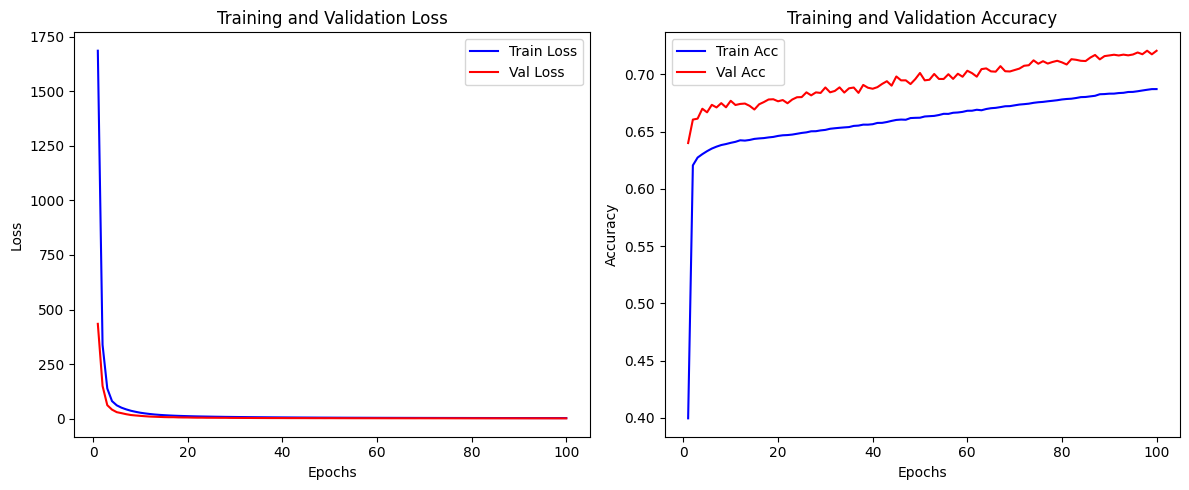

In [254]:
import os
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

def calculate_accuracy(real, pred):
    real = real.to(device)
    pred = pred.to(device)
    mask = (real != 0)
    pred_classes = pred.argmax(dim=-1)
    correct = (pred_classes == real) & mask
    return correct.sum().float() / mask.sum().float()

# --- 수정 전 ---
# EPOCHS = 30
# patience = 5

# --- 수정 후 ---
# 충분한 학습을 위해 EPOCHS를 늘리고, 훈련이 너무 일찍 종료되는 것을 막기 위해 patience를 늘립니다.
EPOCHS = 100          # 30 -> 100: 학습을 더 오래 진행
patience = 10         # 5 -> 10: Validation loss가 10번 연속 개선되지 않을 때 멈춤

global_step = 0
best_val_loss = float('inf')
patience_counter = 0

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
start_epoch = 0
checkpoint_path = 'chatbot_checkpoint.pth'

# --- 모델 구조가 변경되었으므로 이전 체크포인트를 불러오지 않도록 수정합니다 ---
# 하이퍼파라미터를 변경했기 때문에 기존의 가중치를 불러오면 에러가 발생합니다.
print("모델 구조가 변경되었으므로 처음부터 학습을 시작합니다.")

# 체크포인트 로드 (중단된 학습 이어서 하기) - 주석 처리
# if os.path.exists(checkpoint_path):
#     print(f"체크포인트 {checkpoint_path}를 불러옵니다...")
#     checkpoint = torch.load(checkpoint_path)
#     transformer.load_state_dict(checkpoint['model_state_dict'])
#     optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
#     start_epoch = checkpoint['epoch'] + 1
#     global_step = checkpoint['global_step']
#     best_val_loss = checkpoint['best_val_loss']
#     history = checkpoint['history']
#     patience_counter = checkpoint['patience_counter']
#     print(f"Epoch {start_epoch+1}부터 학습을 재개합니다.")

for epoch in range(start_epoch, EPOCHS):
    transformer.train()
    train_loss = 0.0
    train_acc = 0.0

    train_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for src, tgt in train_bar:
        global_step += 1
        lr = learning_rate(global_step)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        optimizer.zero_grad()
        tgt_in = tgt[:, :-1]
        gold = tgt[:, 1:]
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

        src = src.to(device)
        tgt_in = tgt_in.to(device)
        enc_mask = enc_mask.to(device)
        dec_enc_mask = dec_enc_mask.to(device)
        dec_mask = dec_mask.to(device)

        predictions, _, _, _ = transformer(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
        loss = loss_function(gold, predictions)
        acc = calculate_accuracy(gold, predictions)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc += acc.item()
        train_bar.set_postfix({"Loss": f"{loss.item():.4f}", "Acc": f"{acc.item():.4f}"})

    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    # Validation Step
    transformer.eval()
    val_loss = 0.0
    val_acc = 0.0

    val_bar = tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")
    with torch.no_grad():
        for src, tgt in val_bar:
            tgt_in = tgt[:, :-1]
            gold = tgt[:, 1:]
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

            src = src.to(device)
            tgt_in = tgt_in.to(device)
            enc_mask = enc_mask.to(device)
            dec_enc_mask = dec_enc_mask.to(device)
            dec_mask = dec_mask.to(device)

            predictions, _, _, _ = transformer(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
            loss = loss_function(gold, predictions)
            acc = calculate_accuracy(gold, predictions)

            val_loss += loss.item()
            val_acc += acc.item()
            val_bar.set_postfix({"Loss": f"{loss.item():.4f}", "Acc": f"{acc.item():.4f}"})

    val_loss /= len(val_dataloader)
    val_acc /= len(val_dataloader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # 체크포인트 저장
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': transformer.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'global_step': global_step,
        'best_val_loss': best_val_loss,
        'history': history,
        'patience_counter': patience_counter
    }
    torch.save(checkpoint, checkpoint_path)

    # Early Stopping 검사
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(transformer.state_dict(), 'best_transformer.pth')
        print("최적의 모델 저장 완료!")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}!")
            break

if os.path.exists('best_transformer.pth'):
    transformer.load_state_dict(torch.load('best_transformer.pth'))
transformer.eval()

# 결과 시각화
epochs_range = range(1, len(history['train_loss']) + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss')
plt.plot(epochs_range, history['val_loss'], 'r-', label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], 'b-', label='Train Acc')
plt.plot(epochs_range, history['val_acc'], 'r-', label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


### **Step 7. 성능 측정하기**
---
답변을 생성해보고 성능을 확인합니다.

챗봇의 경우, 올바른 대답을 하는지가 중요한 평가 지표입니다. 올바른 답변을 하는지 눈으로 확인할 수 있겠지만, 많은 데이터의 경우는 모든 결과를 확인할 수 없을 것입니다. 주어진 질문에 적절한 답변을 하는지 확인하고, BLEU Score를 계산하는 `calculate_bleu()` 함수도 적용해 보세요.

In [255]:
def evaluate_chatbot(sentence, model, tokenizer):
    clean_sentence = preprocess_sentence(sentence)
    tokens = mecab.morphs(clean_sentence)
    encoded = tokenizer.encode_as_ids(" ".join(tokens))

    result = translate(encoded, model, tokenizer, tokenizer)
    return result

examples = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야."
]

for ex in examples:
    print(f"Q: {ex}")
    ans = evaluate_chatbot(ex, transformer, tokenizer)
    print(f"A: {ans}\n")

Q: 지루하다, 놀러가고 싶어.
A: start> 그래도 배울 점 이 없 어요 .

Q: 오늘 일찍 일어났더니 피곤하다.
A: start> 이제 최선 의 편린 시간 이 에요 .

Q: 간만에 여자친구랑 데이트 하기로 했어.
A: start> 마음 이 허전 함 이 었 나 봐요 .

Q: 집에 있는다는 소리야.
A: start> 잘 지낼 거 예요 .



### **챗봇 성능 측정하기: BLEU Score (Greedy Decoding)**
---
챗봇 데이터 형식(형태소 분석 및 띄어쓰기)에 맞게 수정하여 BLEU 점수를 측정합니다.

In [256]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def eval_bleu_single_chatbot(model, src_sentence, tgt_sentence, tokenizer, verbose=True):
    # 정답 텍스트 정제 및 형태소 토큰화
    clean_tgt = preprocess_sentence(tgt_sentence)
    tgt_tokens = mecab.morphs(clean_tgt)

    # 모델 예측 (Greedy)
    candidate_str = evaluate_chatbot(src_sentence, model, tokenizer)
    candidate_tokens = candidate_str.split()

    score = sentence_bleu([tgt_tokens], candidate_tokens,
                          smoothing_function=SmoothingFunction().method1)

    if verbose:
        print("Source Sentence: ", src_sentence)
        print("Model Prediction: ", candidate_tokens)
        print("Real: ", tgt_tokens)
        print("Score: %lf\n" % score)

    return score

# 원본 데이터(questions, answers)에서 일부를 추출하여 테스트합니다.
test_samples = list(zip(questions[:5], answers[:5]))

print("=== Greedy Decoding BLEU ===")
for q, a in test_samples:
    eval_bleu_single_chatbot(transformer, q, a, tokenizer)

=== Greedy Decoding BLEU ===
Source Sentence:  12시 땡!
Model Prediction:  ['start>', '오늘', '하루', '이', '김', '에', '꼭', '하', '신가', '봐요', '.']
Real:  ['하루', '가', '또', '가', '네요', '.']
Score: 0.022417

Source Sentence:  1지망 학교 떨어졌어
Model Prediction:  ['start>', '위로', '를', '드립니다', '.']
Real:  ['위로', '해', '드립니다', '.']
Score: 0.125743

Source Sentence:  3박4일 놀러가고 싶다
Model Prediction:  ['start>', '여행', '은', '여행', '은', '아무', '도', '좋', '을', '거', '예요', '.']
Real:  ['여행', '은', '언제나', '좋', '죠', '.']
Score: 0.042836

Source Sentence:  3박4일 정도 놀러가고 싶다
Model Prediction:  ['start>', '잘', '지내', '세요', '.']
Real:  ['여행', '은', '언제나', '좋', '죠', '.']
Score: 0.043989

Source Sentence:  PPL 심하네
Model Prediction:  ['start>', '눈살', '이', '찌푸려', '지', '않', '았', '을', '거', '예요', '.']
Real:  ['눈살', '이', '찌푸려', '지', '죠', '.']
Score: 0.248084



### **챗봇 성능 측정하기: Beam Search Decoder**
---
Beam Search를 챗봇 모델에 적용하고 BLEU 점수를 평가해봅니다.

In [257]:
def evaluate_chatbot_beam(sentence, model, tokenizer, beam_size=5):
    clean_sentence = preprocess_sentence(sentence)
    tokens = mecab.morphs(clean_sentence)

    # beam_search_decoder는 내부에서 tokenizer.encode_as_ids(sentence)를 사용하므로
    # 띄어쓰기로 연결된 형태소 문자열을 전달합니다.
    joined_tokens = " ".join(tokens)

    ids = beam_search_decoder(joined_tokens,
                              MAX_LEN,
                              MAX_LEN,
                              model,
                              tokenizer,
                              tokenizer,
                              beam_size)
    return ids

def beam_bleu_chatbot(reference, ids, tokenizer):
    clean_tgt = preprocess_sentence(reference)
    reference_tokens = mecab.morphs(clean_tgt)

    total_score = 0.0
    num_candidates = len(ids)
    if num_candidates == 0:
        return 0.0

    for candidate_ids in ids:
        candidate_str = tokenizer.decode_ids(candidate_ids)
        candidate_tokens = candidate_str.split()

        score = sentence_bleu([reference_tokens], candidate_tokens,
                              smoothing_function=SmoothingFunction().method1)

        print("Reference:", reference_tokens)
        print("Candidate:", candidate_tokens)
        print("BLEU:", score)

        total_score += score

    return total_score / num_candidates

print("=== Beam Search Decoding BLEU ===")
for q, a in test_samples[:3]:
    print(f"Q: {q}")
    ids = evaluate_chatbot_beam(q, transformer, tokenizer, beam_size=5)
    avg_bleu = beam_bleu_chatbot(a, ids, tokenizer)
    print(f"Average BLEU: {avg_bleu}")
    print("-" * 40)

=== Beam Search Decoding BLEU ===
Q: 12시 땡!
Reference: ['하루', '가', '또', '가', '네요', '.']
Candidate: ['이', '죠', '.', '<end>', '건강', '이', '죠', '.', '<end>', '죠', '.', '<end>', '<end>', '<end>', '죠', '.', '<en']
BLEU: 0.011502783619900045
Reference: ['하루', '가', '또', '가', '네요', '.']
Candidate: ['이', '죠', '.', '<end>', '건강', '이', '죠', '.', '<end>', '죠', '.', '<end>', '<end>', '죠end>', '죠', '.', '<en']
BLEU: 0.011502783619900045
Reference: ['하루', '가', '또', '가', '네요', '.']
Candidate: ['이', '죠', '.', '<end>', '건강', '이', '었', '.', '<end>', '죠', '.', '<end>', '<end>', '<end>', '죠', '.', '<en']
BLEU: 0.011502783619900045
Reference: ['하루', '가', '또', '가', '네요', '.']
Candidate: ['이', '죠', '.', '<end>', '건강', '이', '죠', '.', '<end>', '죠', '.', '<end>', '<end>', '.end>', '죠', '.', '<en']
BLEU: 0.011502783619900045
Reference: ['하루', '가', '또', '가', '네요', '.']
Candidate: ['이', '죠', '.', '<end>', '건강', '을', '죠', '.', '<end>', '죠', '.', '<end>', '<end>', '<end>', '죠', '.', '<en']
BLEU: 0.011502783619900045
A